In [1]:
pip install nibabel

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.idi.ntnu.no

[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import torch
import glob
import os
from sklearn.model_selection import train_test_split
from monai.data import CacheDataset, DataLoader, Dataset, list_data_collate
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from transforms import get_train_transforms, get_val_transforms, get_test_transforms
from model import get_model
from loss import loss_functions
from train import train_and_validate
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import config
from utils import dice_debug,analyze_validation_outputs, compute_dice_manual, dice_debug,save_ranked_predictions_for_slicer
from sklearn.model_selection import train_test_split
from dataset import get_dataloaders
import numpy as np
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
2025-05-01 10:43:35.485037: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-01 10:43:35.508533: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-01 10:43:35.904177: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find Tensor

In [2]:
# === Reduced Dataset for Fast Preselection ===
base_dir = "/datasets/tdt4265/mic/open/HNTS-MRG/train"
patients = sorted(glob.glob(os.path.join(base_dir, "*")))

train_files = []
for p in patients[:10]:  # Only use 10 patients for now
    t2_glob = glob.glob(os.path.join(p, "preRT", "*T2.nii.gz"))
    mask_glob = glob.glob(os.path.join(p, "preRT", "*mask.nii.gz"))
    if len(t2_glob) == 1 and len(mask_glob) == 1:
        train_files.append({"image": t2_glob[0], "label": mask_glob[0]})
    else:
        print(f"Skipping {p} (found {len(t2_glob)} T2, {len(mask_glob)} masks)")

train_split, val_split = train_test_split(train_files, test_size=0.2, random_state=42)

# === Dataloaders with small batch and fast config ===
train_ds = CacheDataset(data=train_split, transform=get_train_transforms(), cache_rate=0.0, num_workers=2)
val_ds = CacheDataset(data=val_split, transform=get_val_transforms(), cache_rate=0.0, num_workers=2)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=2, persistent_workers=False)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=2, persistent_workers=False)

/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)



=== Training Model: unet | Loss: bce_dice ===

Epoch 1/20


/home/marcosba/Downloads/medical_segmentation_project/train.py:43: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/home/marcosba/Downloads/medical_segmentation_project/train.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


   [DEBUG] Loss: 0.956935
   [DEBUG] Loss: 0.934592
   [DEBUG] Loss: 0.909605
   [DEBUG] Loss: 0.917302
   [DEBUG] Loss: 0.907699
   [DEBUG] Loss: 0.909548
   [DEBUG] Loss: 0.922676
   [DEBUG] Loss: 0.925732
   🔹 Avg Train Loss: 0.9230
   [DEBUG] Val Output Mean: 0.517130, Max: 0.999999
   [DEBUG] Soft Dice (pre-threshold): 0.029515
   [DEBUG] Val Output Mean: 0.519183, Max: 0.999997
   [DEBUG] Soft Dice (pre-threshold): 0.015497
   🎯 Validation Dice (thresholded): 0.0000

Epoch 2/20
   [DEBUG] Loss: 0.903574
   [DEBUG] Loss: 0.904608
   [DEBUG] Loss: 0.893755
   [DEBUG] Loss: 0.913070
   [DEBUG] Loss: 0.919658
   [DEBUG] Loss: 0.896686
   [DEBUG] Loss: 0.904731
   [DEBUG] Loss: 0.897308
   🔹 Avg Train Loss: 0.9042
   [DEBUG] Val Output Mean: 0.508129, Max: 0.997449
   [DEBUG] Soft Dice (pre-threshold): 0.030359
   [DEBUG] Val Output Mean: 0.508982, Max: 0.995756
   [DEBUG] Soft Dice (pre-threshold): 0.016025
   🎯 Validation Dice (thresholded): 0.0000
   ⚠️ No soft Dice improvement. Co

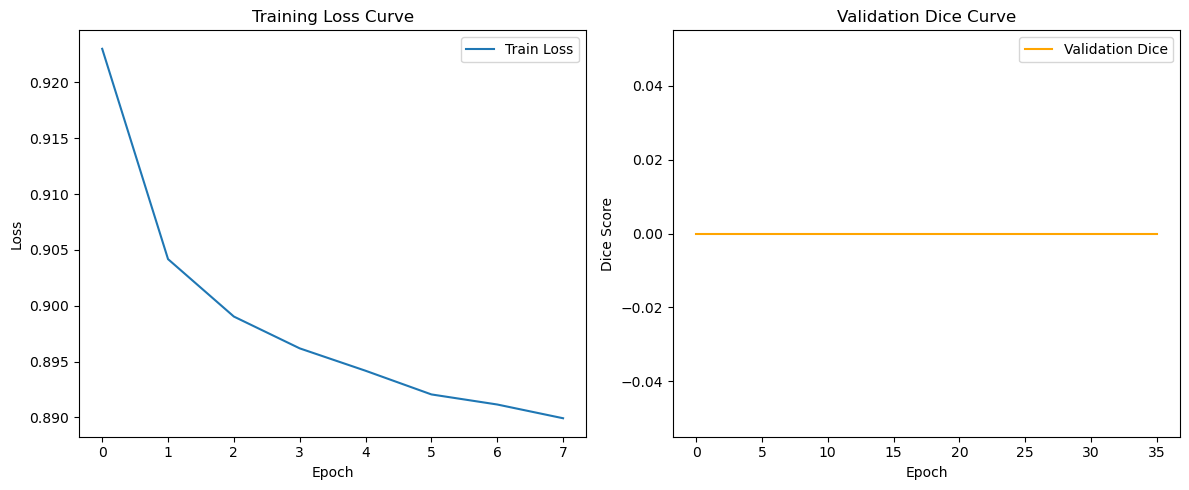


=== Training Model: unet | Loss: dice ===

Epoch 1/20
   [DEBUG] Loss: 0.987834
   [DEBUG] Loss: 0.996914
   [DEBUG] Loss: 0.968686
   [DEBUG] Loss: 0.983910
   [DEBUG] Loss: 0.974340
   [DEBUG] Loss: 0.986164
   [DEBUG] Loss: 0.973761
   [DEBUG] Loss: 0.972780
   🔹 Avg Train Loss: 0.9805
   [DEBUG] Val Output Mean: 0.478456, Max: 0.922063
   [DEBUG] Soft Dice (pre-threshold): 0.027531
   [DEBUG] Val Output Mean: 0.477204, Max: 0.911316
   [DEBUG] Soft Dice (pre-threshold): 0.014450
   🎯 Validation Dice (thresholded): 0.0000

Epoch 2/20
   [DEBUG] Loss: 0.970484
   [DEBUG] Loss: 0.985633
   [DEBUG] Loss: 0.966596
   [DEBUG] Loss: 0.982081
   [DEBUG] Loss: 0.996324
   [DEBUG] Loss: 0.984092
   [DEBUG] Loss: 0.970533
   [DEBUG] Loss: 0.966972
   🔹 Avg Train Loss: 0.9778
   [DEBUG] Val Output Mean: 0.463780, Max: 0.923948
   [DEBUG] Soft Dice (pre-threshold): 0.029535
   [DEBUG] Val Output Mean: 0.462541, Max: 0.877121
   [DEBUG] Soft Dice (pre-threshold): 0.015802
   🎯 Validation Dice (

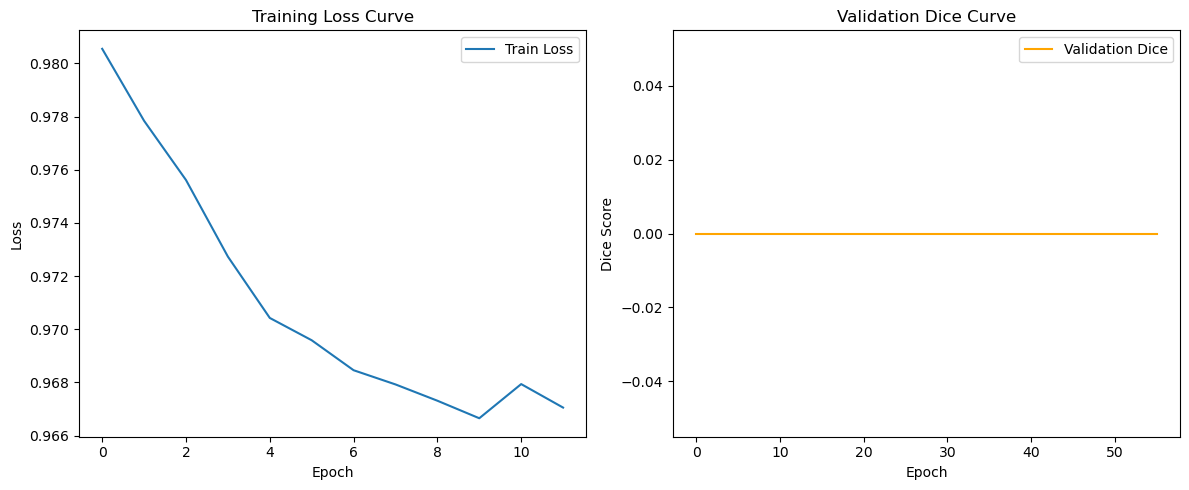


=== Training Model: unet | Loss: tversky ===

Epoch 1/20
   [DEBUG] Loss: 0.997893
   [DEBUG] Loss: 0.974593
   [DEBUG] Loss: 0.984619
   [DEBUG] Loss: 0.986706
   [DEBUG] Loss: 0.970497
   [DEBUG] Loss: 0.966081
   [DEBUG] Loss: 0.973250
   [DEBUG] Loss: 0.982777
   🔹 Avg Train Loss: 0.9796
   [DEBUG] Val Output Mean: 0.517239, Max: 1.000000
   [DEBUG] Soft Dice (pre-threshold): 0.043696
   [DEBUG] Val Output Mean: 0.517173, Max: 0.999999
   [DEBUG] Soft Dice (pre-threshold): 0.022426
   🎯 Validation Dice (thresholded): 0.0000

Epoch 2/20
   [DEBUG] Loss: 0.966929
   [DEBUG] Loss: 0.971726
   [DEBUG] Loss: 0.971494
   [DEBUG] Loss: 0.996283
   [DEBUG] Loss: 0.986282
   [DEBUG] Loss: 0.971734
   [DEBUG] Loss: 0.983111
   [DEBUG] Loss: 0.982044
   🔹 Avg Train Loss: 0.9787
   [DEBUG] Val Output Mean: 0.512101, Max: 1.000000
   [DEBUG] Soft Dice (pre-threshold): 0.044688
   [DEBUG] Val Output Mean: 0.511638, Max: 0.999999
   [DEBUG] Soft Dice (pre-threshold): 0.022977
   🎯 Validation Dic

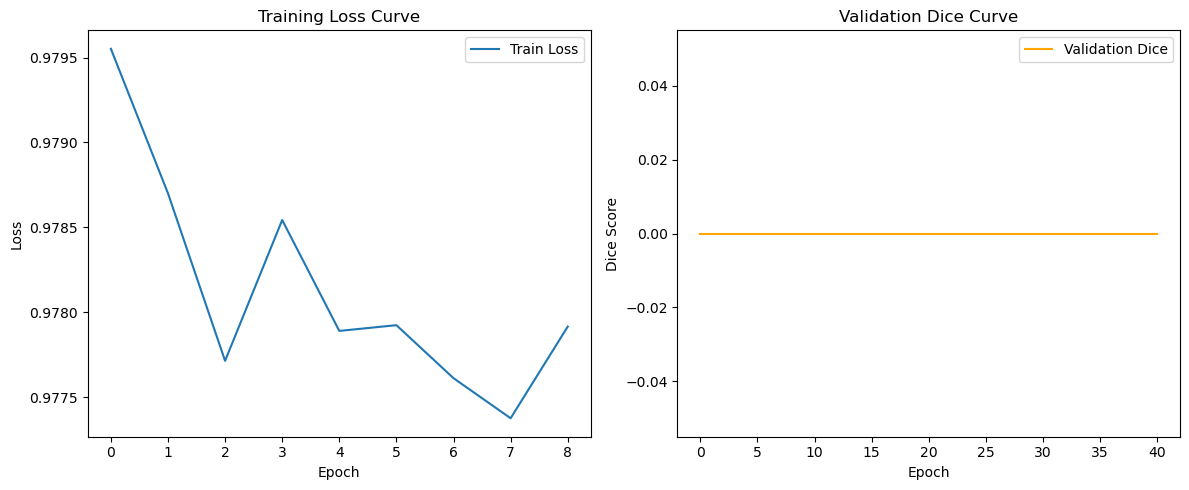


=== Training Model: dynunet_no_ds | Loss: bce_dice ===

Epoch 1/20
   [DEBUG] Loss: 0.930594
   [DEBUG] Loss: 0.895948
   [DEBUG] Loss: 0.870457
   [DEBUG] Loss: 0.882032
   [DEBUG] Loss: 0.874904
   [DEBUG] Loss: 0.842243
   [DEBUG] Loss: 0.837789
   [DEBUG] Loss: 0.868459
   🔹 Avg Train Loss: 0.8753
   [DEBUG] Val Output Mean: 0.366392, Max: 0.999985
   [DEBUG] Soft Dice (pre-threshold): 0.050522
   [DEBUG] Val Output Mean: 0.366296, Max: 0.999989
   [DEBUG] Soft Dice (pre-threshold): 0.027480
   🎯 Validation Dice (thresholded): 0.0000

Epoch 2/20
   [DEBUG] Loss: 0.859968
   [DEBUG] Loss: 0.843464
   [DEBUG] Loss: 0.813077
   [DEBUG] Loss: 0.821615
   [DEBUG] Loss: 0.804950
   [DEBUG] Loss: 0.803494
   [DEBUG] Loss: 0.801503
   [DEBUG] Loss: 0.806664
   🔹 Avg Train Loss: 0.8193
   [DEBUG] Val Output Mean: 0.330754, Max: 0.999997
   [DEBUG] Soft Dice (pre-threshold): 0.053969
   [DEBUG] Val Output Mean: 0.332081, Max: 0.999992
   [DEBUG] Soft Dice (pre-threshold): 0.030699
   🎯 Vali

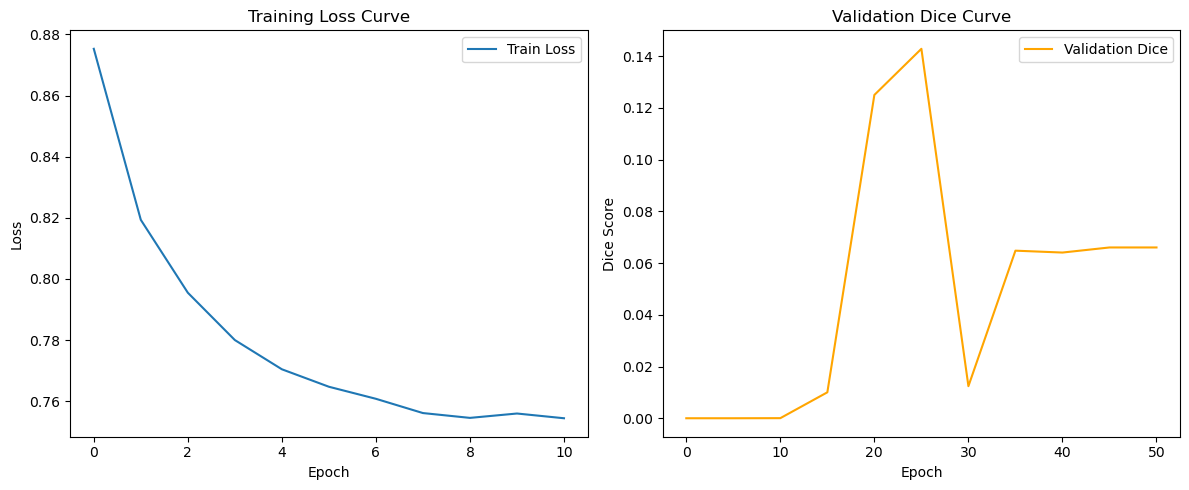


=== Training Model: dynunet_no_ds | Loss: dice ===

Epoch 1/20
   [DEBUG] Loss: 0.981050
   [DEBUG] Loss: 0.979493
   [DEBUG] Loss: 0.959904
   [DEBUG] Loss: 0.948911
   [DEBUG] Loss: 0.993955
   [DEBUG] Loss: 0.955148
   [DEBUG] Loss: 0.971463
   [DEBUG] Loss: 0.978698
   🔹 Avg Train Loss: 0.9711
   [DEBUG] Val Output Mean: 0.400398, Max: 0.999992
   [DEBUG] Soft Dice (pre-threshold): 0.055539
   [DEBUG] Val Output Mean: 0.398171, Max: 0.999991
   [DEBUG] Soft Dice (pre-threshold): 0.029091
   🎯 Validation Dice (thresholded): 0.0000

Epoch 2/20
   [DEBUG] Loss: 0.954749
   [DEBUG] Loss: 0.952293
   [DEBUG] Loss: 0.942083
   [DEBUG] Loss: 0.975372
   [DEBUG] Loss: 0.952579
   [DEBUG] Loss: 0.968880
   [DEBUG] Loss: 0.993151
   [DEBUG] Loss: 0.969596
   🔹 Avg Train Loss: 0.9636
   [DEBUG] Val Output Mean: 0.372055, Max: 0.999992
   [DEBUG] Soft Dice (pre-threshold): 0.060249
   [DEBUG] Val Output Mean: 0.370872, Max: 0.999989
   [DEBUG] Soft Dice (pre-threshold): 0.031354
   🎯 Validati

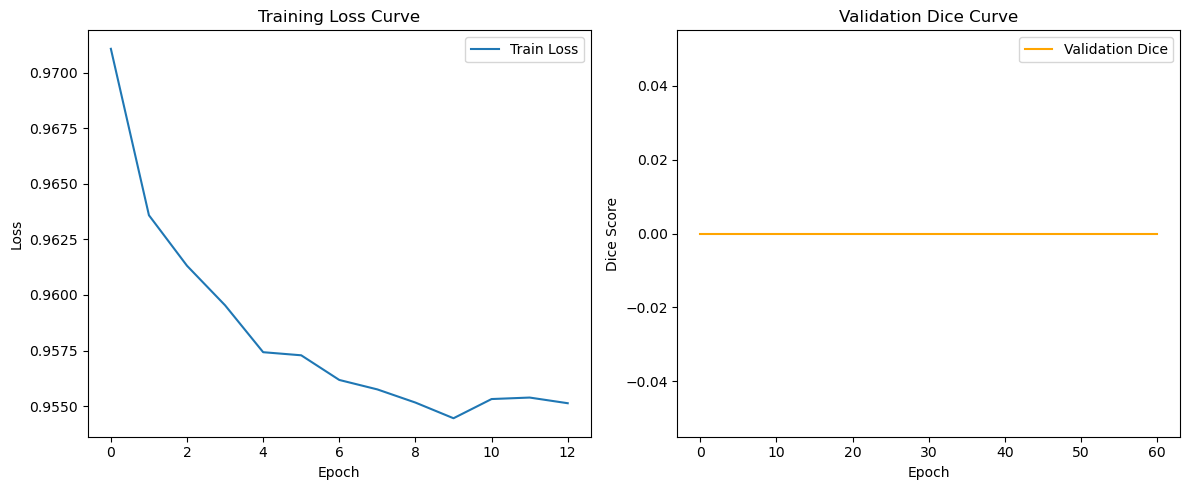


=== Training Model: dynunet_no_ds | Loss: tversky ===

Epoch 1/20
   [DEBUG] Loss: 0.989501
   [DEBUG] Loss: 0.975139
   [DEBUG] Loss: 0.985482
   [DEBUG] Loss: 0.980120
   [DEBUG] Loss: 0.960022
   [DEBUG] Loss: 0.995867
   [DEBUG] Loss: 0.964231
   [DEBUG] Loss: 0.978036
   🔹 Avg Train Loss: 0.9785
   [DEBUG] Val Output Mean: 0.353867, Max: 0.999996
   [DEBUG] Soft Dice (pre-threshold): 0.061225
   [DEBUG] Val Output Mean: 0.348894, Max: 0.999982
   [DEBUG] Soft Dice (pre-threshold): 0.032796
   🎯 Validation Dice (thresholded): 0.0000

Epoch 2/20
   [DEBUG] Loss: 0.963842
   [DEBUG] Loss: 0.995509
   [DEBUG] Loss: 0.976391
   [DEBUG] Loss: 0.952423
   [DEBUG] Loss: 0.964279
   [DEBUG] Loss: 0.964248
   [DEBUG] Loss: 0.978868
   [DEBUG] Loss: 0.983009
   🔹 Avg Train Loss: 0.9723
   [DEBUG] Val Output Mean: 0.328508, Max: 0.999970
   [DEBUG] Soft Dice (pre-threshold): 0.067539
   [DEBUG] Val Output Mean: 0.321257, Max: 0.999978
   [DEBUG] Soft Dice (pre-threshold): 0.035998
   🎯 Valid

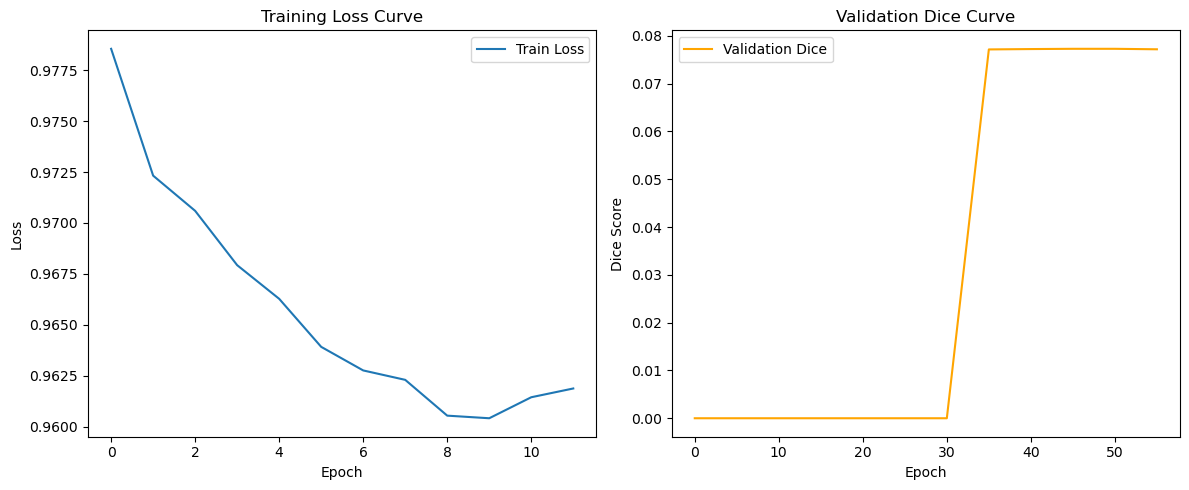


=== Training Model: attention_unet | Loss: bce_dice ===

Epoch 1/20
   [DEBUG] Loss: 0.939367
   [DEBUG] Loss: 0.935367
   [DEBUG] Loss: 0.947999
   [DEBUG] Loss: 0.908272
   [DEBUG] Loss: 0.906907
   [DEBUG] Loss: 0.917929
   [DEBUG] Loss: 0.898904
   [DEBUG] Loss: 0.909293
   🔹 Avg Train Loss: 0.9205
   [DEBUG] Val Output Mean: 0.536649, Max: 0.999684
   [DEBUG] Soft Dice (pre-threshold): 0.026797
   [DEBUG] Val Output Mean: 0.502064, Max: 0.999999
   [DEBUG] Soft Dice (pre-threshold): 0.019919
   🎯 Validation Dice (thresholded): 0.0000

Epoch 2/20
   [DEBUG] Loss: 0.892372
   [DEBUG] Loss: 0.912343
   [DEBUG] Loss: 0.900445
   [DEBUG] Loss: 0.883938
   [DEBUG] Loss: 0.881795
   [DEBUG] Loss: 0.902164
   [DEBUG] Loss: 0.915153
   [DEBUG] Loss: 0.878489
   🔹 Avg Train Loss: 0.8958
   [DEBUG] Val Output Mean: 0.494666, Max: 0.999997
   [DEBUG] Soft Dice (pre-threshold): 0.029098
   [DEBUG] Val Output Mean: 0.472974, Max: 0.999861
   [DEBUG] Soft Dice (pre-threshold): 0.022071
   🎯 Val

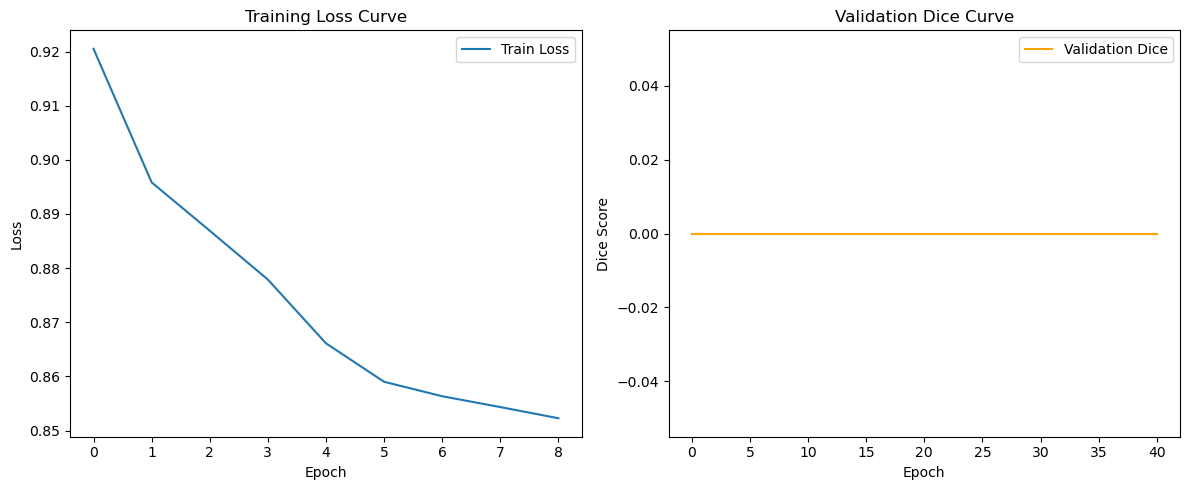


=== Training Model: attention_unet | Loss: dice ===

Epoch 1/20
   [DEBUG] Loss: 0.994128
   [DEBUG] Loss: 0.994538
   [DEBUG] Loss: 0.949420
   [DEBUG] Loss: 0.969783
   [DEBUG] Loss: 0.976723
   [DEBUG] Loss: 0.951541
   [DEBUG] Loss: 0.970825
   [DEBUG] Loss: 0.937202
   🔹 Avg Train Loss: 0.9680
   [DEBUG] Val Output Mean: 0.404324, Max: 1.000000
   [DEBUG] Soft Dice (pre-threshold): 0.044012
   [DEBUG] Val Output Mean: 0.392348, Max: 0.999997
   [DEBUG] Soft Dice (pre-threshold): 0.027855
   🎯 Validation Dice (thresholded): 0.0000

Epoch 2/20
   [DEBUG] Loss: 0.976098
   [DEBUG] Loss: 0.948300
   [DEBUG] Loss: 0.968314
   [DEBUG] Loss: 0.950016
   [DEBUG] Loss: 0.993373
   [DEBUG] Loss: 0.938968
   [DEBUG] Loss: 0.969324
   [DEBUG] Loss: 0.949628
   🔹 Avg Train Loss: 0.9618
   [DEBUG] Val Output Mean: 0.378874, Max: 0.999900
   [DEBUG] Soft Dice (pre-threshold): 0.055137
   [DEBUG] Val Output Mean: 0.373868, Max: 0.999942
   [DEBUG] Soft Dice (pre-threshold): 0.030212
   🎯 Validat

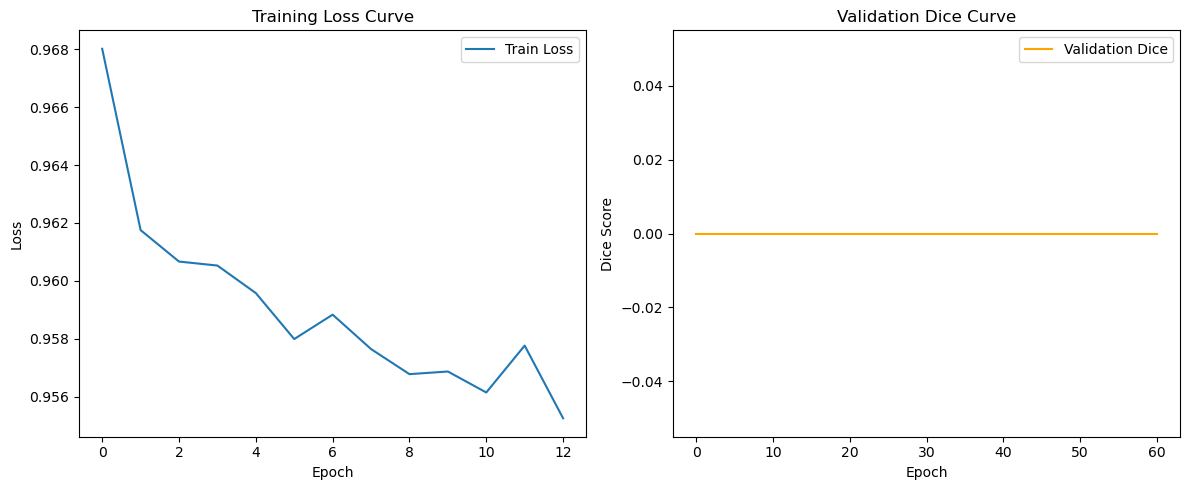


=== Training Model: attention_unet | Loss: tversky ===

Epoch 1/20
   [DEBUG] Loss: 0.995759
   [DEBUG] Loss: 0.971727
   [DEBUG] Loss: 0.980530
   [DEBUG] Loss: 0.964588
   [DEBUG] Loss: 0.953523
   [DEBUG] Loss: 0.995285
   [DEBUG] Loss: 0.978584
   [DEBUG] Loss: 0.968129
   🔹 Avg Train Loss: 0.9760
   [DEBUG] Val Output Mean: 0.425884, Max: 1.000000
   [DEBUG] Soft Dice (pre-threshold): 0.043892
   [DEBUG] Val Output Mean: 0.416878, Max: 1.000000
   [DEBUG] Soft Dice (pre-threshold): 0.026520
   🎯 Validation Dice (thresholded): 0.0000

Epoch 2/20
   [DEBUG] Loss: 0.965280
   [DEBUG] Loss: 0.969045
   [DEBUG] Loss: 0.979209
   [DEBUG] Loss: 0.995457
   [DEBUG] Loss: 0.979717
   [DEBUG] Loss: 0.956943
   [DEBUG] Loss: 0.964843
   [DEBUG] Loss: 0.983772
   🔹 Avg Train Loss: 0.9743
   [DEBUG] Val Output Mean: 0.390486, Max: 0.999744
   [DEBUG] Soft Dice (pre-threshold): 0.056969
   [DEBUG] Val Output Mean: 0.381757, Max: 0.999740
   [DEBUG] Soft Dice (pre-threshold): 0.030207
   🎯 Vali

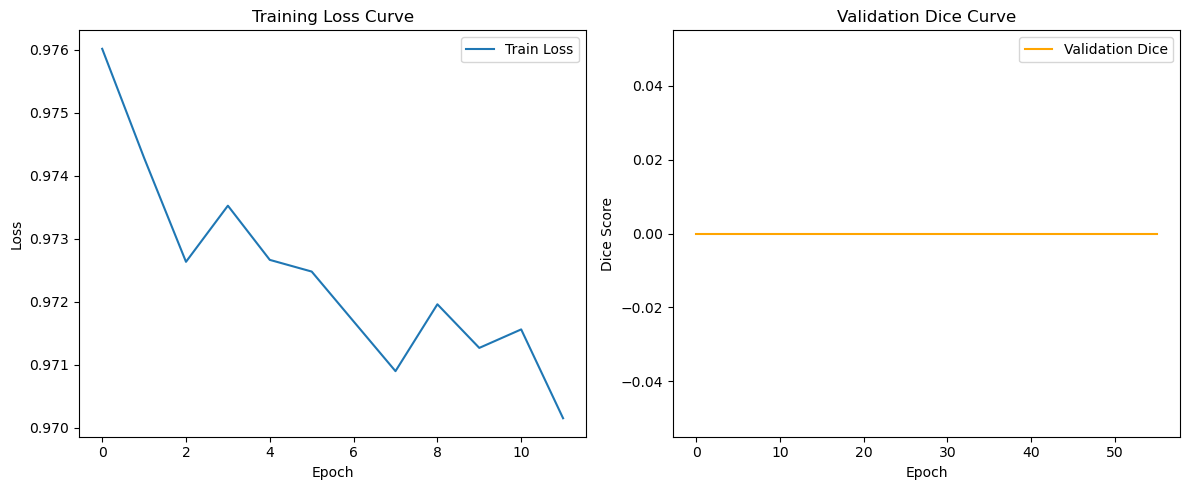


===== Summary of Preselection Results =====
Model:            unet, Loss:   bce_dice, Best Dice: 0.0000
Model:            unet, Loss:       dice, Best Dice: 0.0000
Model:            unet, Loss:    tversky, Best Dice: 0.0000
Model:   dynunet_no_ds, Loss:   bce_dice, Best Dice: 0.1429
Model:   dynunet_no_ds, Loss:       dice, Best Dice: 0.0000
Model:   dynunet_no_ds, Loss:    tversky, Best Dice: 0.0773
Model:  attention_unet, Loss:   bce_dice, Best Dice: 0.0000
Model:  attention_unet, Loss:       dice, Best Dice: 0.0000
Model:  attention_unet, Loss:    tversky, Best Dice: 0.0000


In [3]:
# === Preselection Loop ===
models_to_try = ["unet", "dynunet_no_ds", "attention_unet"]
losses_to_try = ["bce_dice", "dice", "tversky"]

results = []

for model_name in models_to_try:
    for loss_name in losses_to_try:
        print(f"\n=== Training Model: {model_name} | Loss: {loss_name} ===")

        model = get_model(model_name=model_name)
        loss_fn = loss_functions[loss_name]
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
        scheduler = CosineAnnealingLR(optimizer, T_max=10)  # fast config

        history, best_dice = train_and_validate(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            scheduler=scheduler,
            max_epochs=20,  # Short preselection
            model_path="outputs/",
            save_name=f"{model_name}_{loss_name}_preview.pth",
            validate_every=1,
            fast_until_epoch=20,  # always use fast val
            fast_roi_size=(96, 96, 96),  # smaller patch
            full_roi_size=(96, 96, 96),
            fast_overlap=0.1,
            full_overlap=0.1,
            fast_sw_batch_size=1,
            full_sw_batch_size=1,
            debug=True,
            early_training=True,
            early_stop_patience=5,     
            early_stop_min_delta=0.001
        )

        results.append({
            "model": model_name,
            "loss": loss_name,
            "best_dice": best_dice
        })

# === Print Results Summary ===
print("\n===== Summary of Preselection Results =====")
for res in results:
    print(f"Model: {res['model']:>15}, Loss: {res['loss']:>10}, Best Dice: {res['best_dice']:.4f}")


=== Training Model: unet | Loss: bce_dice ===

Epoch 1/100


/home/marcosba/Downloads/medical_segmentation_project/train.py:44: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/home/marcosba/Downloads/medical_segmentation_project/train.py:71: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


   [DEBUG] Loss: 0.932743
   [DEBUG] Loss: 0.903033
   [DEBUG] Loss: 0.925369
   [DEBUG] Loss: 0.902756
   [DEBUG] Loss: 0.900072
   [DEBUG] Loss: 0.912800
   [DEBUG] Loss: 0.895256
   [DEBUG] Loss: 0.895100
   🔹 Avg Train Loss: 0.9084
   [DEBUG] Val Output Mean: 0.487565, Max: 0.999949
   [DEBUG] Soft Dice (pre-threshold): 0.029893
   [DEBUG] Val Output Mean: 0.488473, Max: 0.999957
   [DEBUG] Soft Dice (pre-threshold): 0.015421
   🎯 Validation Dice (thresholded): 0.0000

Epoch 2/100
   [DEBUG] Loss: 0.890163
   [DEBUG] Loss: 0.890690
   [DEBUG] Loss: 0.882602
   [DEBUG] Loss: 0.901400
   [DEBUG] Loss: 0.889647
   [DEBUG] Loss: 0.905635
   [DEBUG] Loss: 0.882466
   [DEBUG] Loss: 0.891893
   🔹 Avg Train Loss: 0.8918
   [DEBUG] Val Output Mean: 0.483294, Max: 0.999351
   [DEBUG] Soft Dice (pre-threshold): 0.029909
   [DEBUG] Val Output Mean: 0.483934, Max: 0.999398
   [DEBUG] Soft Dice (pre-threshold): 0.015532
   🎯 Validation Dice (thresholded): 0.0000

Epoch 3/100
   [DEBUG] Loss: 0.9

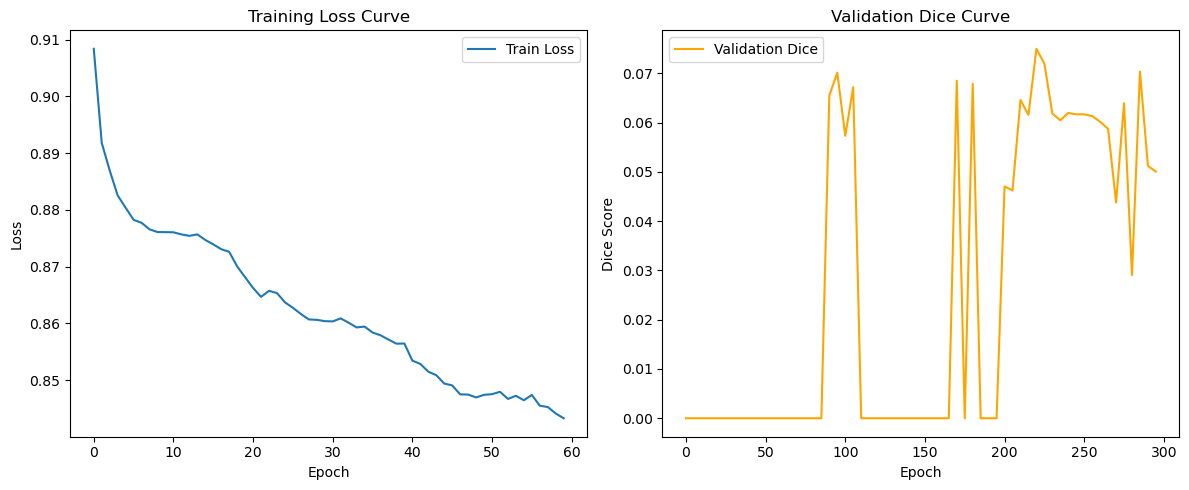


=== Training Model: unet | Loss: dice ===

Epoch 1/100
   [DEBUG] Loss: 0.988231
   [DEBUG] Loss: 0.970115
   [DEBUG] Loss: 0.978035
   [DEBUG] Loss: 0.964057
   [DEBUG] Loss: 0.960840
   [DEBUG] Loss: 0.976390
   [DEBUG] Loss: 0.995108
   [DEBUG] Loss: 0.950926
   🔹 Avg Train Loss: 0.9730
   [DEBUG] Val Output Mean: 0.494904, Max: 0.999988
   [DEBUG] Soft Dice (pre-threshold): 0.042964
   [DEBUG] Val Output Mean: 0.495340, Max: 0.999972
   [DEBUG] Soft Dice (pre-threshold): 0.022310
   🎯 Validation Dice (thresholded): 0.0000

Epoch 2/100
   [DEBUG] Loss: 0.979980
   [DEBUG] Loss: 0.958053
   [DEBUG] Loss: 0.959946
   [DEBUG] Loss: 0.975098
   [DEBUG] Loss: 0.959797
   [DEBUG] Loss: 0.993848
   [DEBUG] Loss: 0.976057
   [DEBUG] Loss: 0.950235
   🔹 Avg Train Loss: 0.9691
   [DEBUG] Val Output Mean: 0.489938, Max: 0.999996
   [DEBUG] Soft Dice (pre-threshold): 0.045500
   [DEBUG] Val Output Mean: 0.490064, Max: 0.999967
   [DEBUG] Soft Dice (pre-threshold): 0.023572
   🎯 Validation Dice

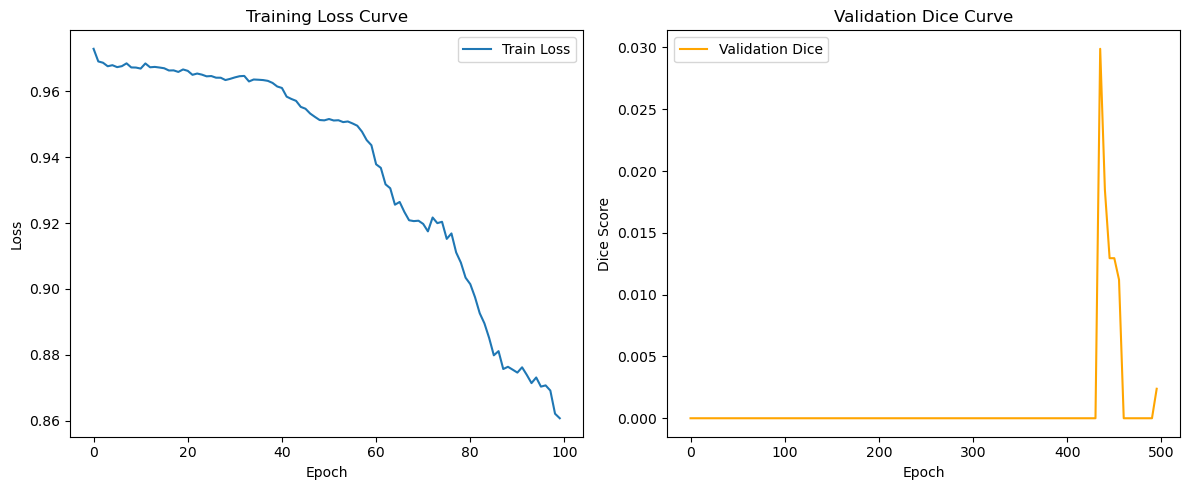


=== Training Model: unet | Loss: tversky ===

Epoch 1/100
   [DEBUG] Loss: 0.983489
   [DEBUG] Loss: 0.987413
   [DEBUG] Loss: 0.987374
   [DEBUG] Loss: 0.971981
   [DEBUG] Loss: 0.976242
   [DEBUG] Loss: 0.996506
   [DEBUG] Loss: 0.987607
   [DEBUG] Loss: 0.971424
   🔹 Avg Train Loss: 0.9828
   [DEBUG] Val Output Mean: 0.492913, Max: 0.999901
   [DEBUG] Soft Dice (pre-threshold): 0.038487
   [DEBUG] Val Output Mean: 0.492963, Max: 0.999873
   [DEBUG] Soft Dice (pre-threshold): 0.019960
   🎯 Validation Dice (thresholded): 0.0000

Epoch 2/100
   [DEBUG] Loss: 0.984905
   [DEBUG] Loss: 0.973920
   [DEBUG] Loss: 0.966187
   [DEBUG] Loss: 0.981975
   [DEBUG] Loss: 0.969788
   [DEBUG] Loss: 0.970165
   [DEBUG] Loss: 0.986011
   [DEBUG] Loss: 0.995947
   🔹 Avg Train Loss: 0.9786
   [DEBUG] Val Output Mean: 0.489645, Max: 0.999852
   [DEBUG] Soft Dice (pre-threshold): 0.043195
   [DEBUG] Val Output Mean: 0.489714, Max: 0.999485
   [DEBUG] Soft Dice (pre-threshold): 0.022423
   🎯 Validation D

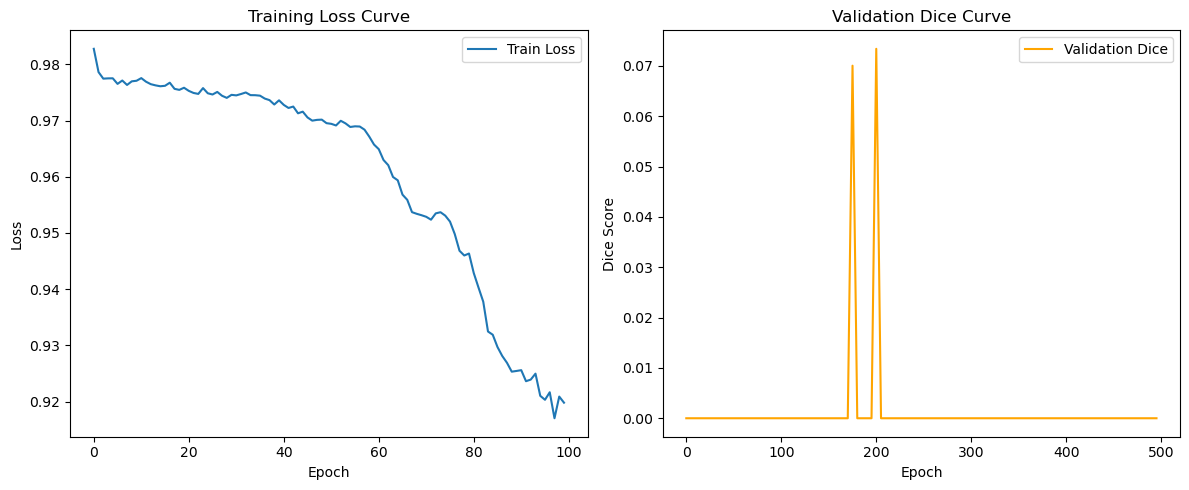


=== Training Model: dynunet_no_ds | Loss: bce_dice ===

Epoch 1/100
   [DEBUG] Loss: 0.903327
   [DEBUG] Loss: 0.865023
   [DEBUG] Loss: 0.872563
   [DEBUG] Loss: 0.853201
   [DEBUG] Loss: 0.868286
   [DEBUG] Loss: 0.833369
   [DEBUG] Loss: 0.845319
   [DEBUG] Loss: 0.860981
   🔹 Avg Train Loss: 0.8628
   [DEBUG] Val Output Mean: 0.393149, Max: 0.978610
   [DEBUG] Soft Dice (pre-threshold): 0.043689
   [DEBUG] Val Output Mean: 0.394864, Max: 0.973266
   [DEBUG] Soft Dice (pre-threshold): 0.023345
   🎯 Validation Dice (thresholded): 0.0000

Epoch 2/100
   [DEBUG] Loss: 0.833685
   [DEBUG] Loss: 0.853123
   [DEBUG] Loss: 0.825314
   [DEBUG] Loss: 0.820542
   [DEBUG] Loss: 0.825639
   [DEBUG] Loss: 0.844764
   [DEBUG] Loss: 0.804209
   [DEBUG] Loss: 0.810583
   🔹 Avg Train Loss: 0.8272
   [DEBUG] Val Output Mean: 0.376251, Max: 0.975492
   [DEBUG] Soft Dice (pre-threshold): 0.040947
   [DEBUG] Val Output Mean: 0.378588, Max: 0.974746
   [DEBUG] Soft Dice (pre-threshold): 0.022519
   🎯 Va

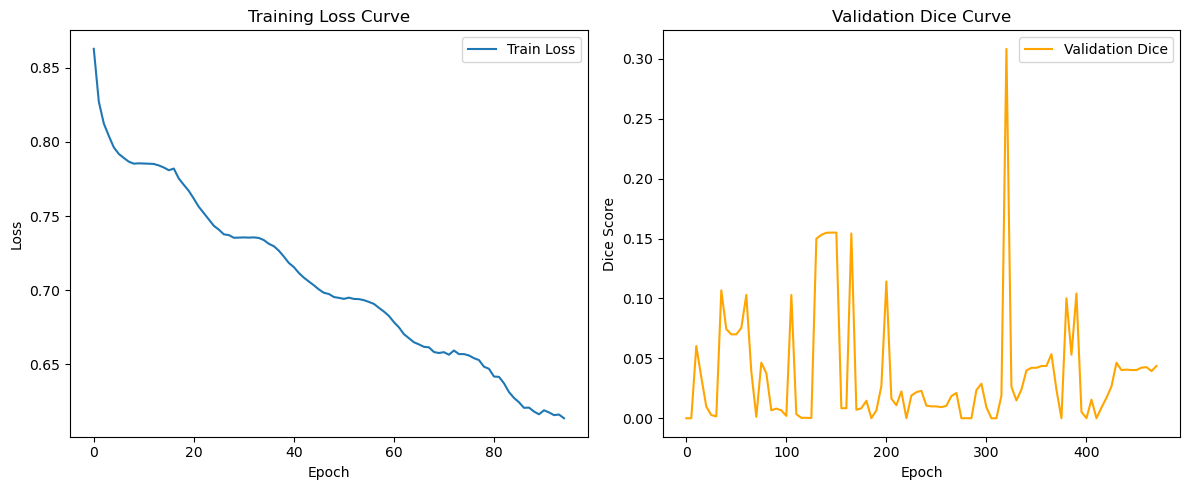


=== Training Model: dynunet_no_ds | Loss: dice ===

Epoch 1/100
   [DEBUG] Loss: 0.994911
   [DEBUG] Loss: 0.978557
   [DEBUG] Loss: 0.948732
   [DEBUG] Loss: 0.947357
   [DEBUG] Loss: 0.966491
   [DEBUG] Loss: 0.934963
   [DEBUG] Loss: 0.945484
   [DEBUG] Loss: 0.965540
   🔹 Avg Train Loss: 0.9603
   [DEBUG] Val Output Mean: 0.287483, Max: 0.999999
   [DEBUG] Soft Dice (pre-threshold): 0.077203
   [DEBUG] Val Output Mean: 0.282466, Max: 0.999998
   [DEBUG] Soft Dice (pre-threshold): 0.041002
   🎯 Validation Dice (thresholded): 0.0000

Epoch 2/100
   [DEBUG] Loss: 0.972517
   [DEBUG] Loss: 0.929088
   [DEBUG] Loss: 0.991883
   [DEBUG] Loss: 0.946382
   [DEBUG] Loss: 0.965387
   [DEBUG] Loss: 0.935157
   [DEBUG] Loss: 0.934605
   [DEBUG] Loss: 0.961535
   🔹 Avg Train Loss: 0.9546
   [DEBUG] Val Output Mean: 0.268555, Max: 1.000000
   [DEBUG] Soft Dice (pre-threshold): 0.080399
   [DEBUG] Val Output Mean: 0.262599, Max: 0.999999
   [DEBUG] Soft Dice (pre-threshold): 0.043639
   🎯 Valida

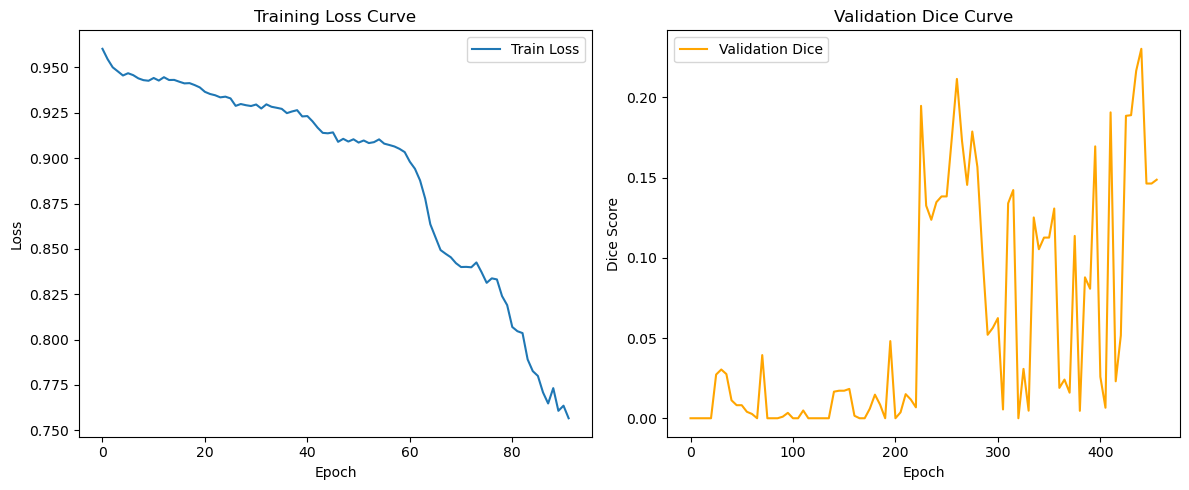


=== Training Model: dynunet_no_ds | Loss: tversky ===

Epoch 1/100
   [DEBUG] Loss: 0.993782
   [DEBUG] Loss: 0.997567
   [DEBUG] Loss: 0.987771
   [DEBUG] Loss: 0.976177
   [DEBUG] Loss: 0.974589
   [DEBUG] Loss: 0.949279
   [DEBUG] Loss: 0.951001
   [DEBUG] Loss: 0.934130
   🔹 Avg Train Loss: 0.9705
   [DEBUG] Val Output Mean: 0.227960, Max: 0.999859
   [DEBUG] Soft Dice (pre-threshold): 0.092399
   [DEBUG] Val Output Mean: 0.228654, Max: 0.999893
   [DEBUG] Soft Dice (pre-threshold): 0.048985
   🎯 Validation Dice (thresholded): 0.0000

Epoch 2/100
   [DEBUG] Loss: 0.974003
   [DEBUG] Loss: 0.966999
   [DEBUG] Loss: 0.943221
   [DEBUG] Loss: 0.945347
   [DEBUG] Loss: 0.923214
   [DEBUG] Loss: 0.961541
   [DEBUG] Loss: 0.937191
   [DEBUG] Loss: 0.990944
   🔹 Avg Train Loss: 0.9553
   [DEBUG] Val Output Mean: 0.197787, Max: 0.999987
   [DEBUG] Soft Dice (pre-threshold): 0.103782
   [DEBUG] Val Output Mean: 0.201225, Max: 0.999987
   [DEBUG] Soft Dice (pre-threshold): 0.055278
   🎯 Val

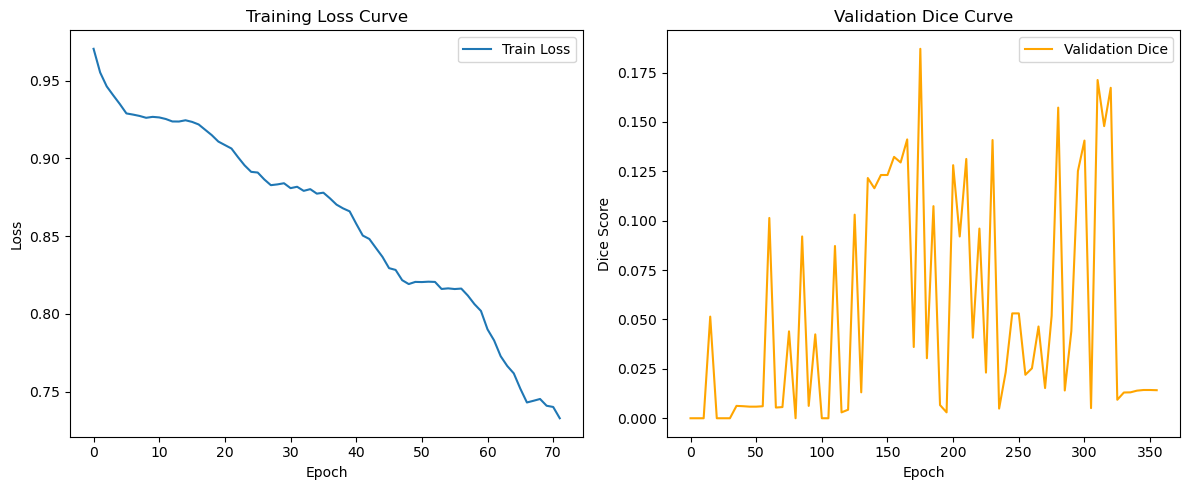


=== Training Model: attention_unet | Loss: bce_dice ===

Epoch 1/100
   [DEBUG] Loss: 0.897785
   [DEBUG] Loss: 0.905876
   [DEBUG] Loss: 0.866887
   [DEBUG] Loss: 0.881181
   [DEBUG] Loss: 0.858473
   [DEBUG] Loss: 0.868865
   [DEBUG] Loss: 0.850825
   [DEBUG] Loss: 0.860821
   🔹 Avg Train Loss: 0.8738
   [DEBUG] Val Output Mean: 0.461961, Max: 0.924985
   [DEBUG] Soft Dice (pre-threshold): 0.023011
   [DEBUG] Val Output Mean: 0.463439, Max: 0.937867
   [DEBUG] Soft Dice (pre-threshold): 0.012572
   🎯 Validation Dice (thresholded): 0.1767
   💾 Best model saved at outputs/attention_unet_bce_dice_preview.pth.

Epoch 2/100
   [DEBUG] Loss: 0.847559
   [DEBUG] Loss: 0.841730
   [DEBUG] Loss: 0.855928
   [DEBUG] Loss: 0.875849
   [DEBUG] Loss: 0.857459
   [DEBUG] Loss: 0.838186
   [DEBUG] Loss: 0.857438
   [DEBUG] Loss: 0.837635
   🔹 Avg Train Loss: 0.8515
   [DEBUG] Val Output Mean: 0.454865, Max: 0.995869
   [DEBUG] Soft Dice (pre-threshold): 0.022440
   [DEBUG] Val Output Mean: 0.45649

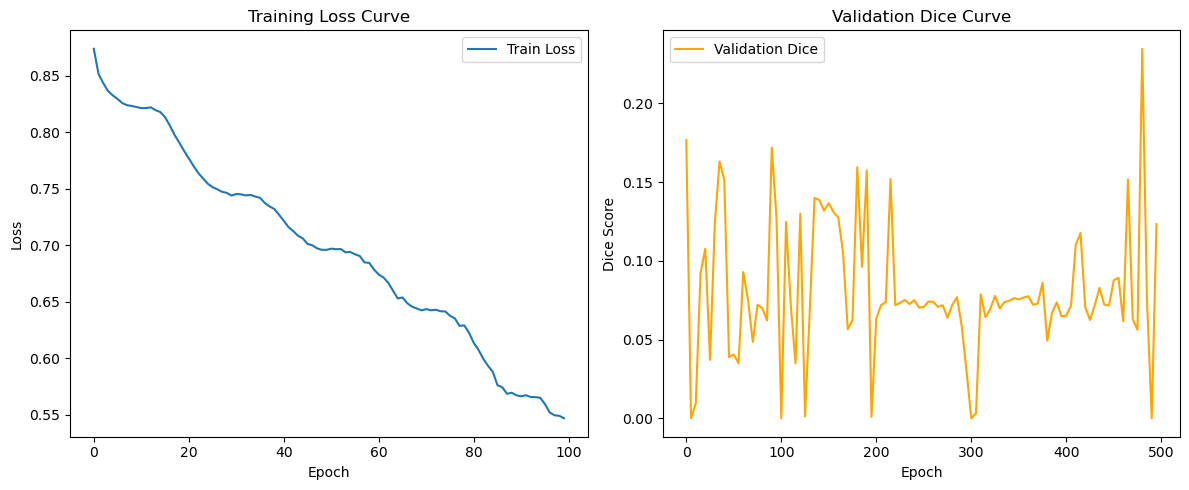


=== Training Model: attention_unet | Loss: dice ===

Epoch 1/100
   [DEBUG] Loss: 0.972439
   [DEBUG] Loss: 0.955100
   [DEBUG] Loss: 0.979252
   [DEBUG] Loss: 0.994501
   [DEBUG] Loss: 0.971156
   [DEBUG] Loss: 0.955557
   [DEBUG] Loss: 0.972505
   [DEBUG] Loss: 0.954332
   🔹 Avg Train Loss: 0.9694
   [DEBUG] Val Output Mean: 0.464291, Max: 1.000000
   [DEBUG] Soft Dice (pre-threshold): 0.037330
   [DEBUG] Val Output Mean: 0.445988, Max: 0.999994
   [DEBUG] Soft Dice (pre-threshold): 0.025392
   🎯 Validation Dice (thresholded): 0.0000

Epoch 2/100
   [DEBUG] Loss: 0.994142
   [DEBUG] Loss: 0.954861
   [DEBUG] Loss: 0.973375
   [DEBUG] Loss: 0.944788
   [DEBUG] Loss: 0.950639
   [DEBUG] Loss: 0.970963
   [DEBUG] Loss: 0.953762
   [DEBUG] Loss: 0.978676
   🔹 Avg Train Loss: 0.9652
   [DEBUG] Val Output Mean: 0.443783, Max: 1.000000
   [DEBUG] Soft Dice (pre-threshold): 0.047156
   [DEBUG] Val Output Mean: 0.438582, Max: 0.999997
   [DEBUG] Soft Dice (pre-threshold): 0.025847
   🎯 Valid

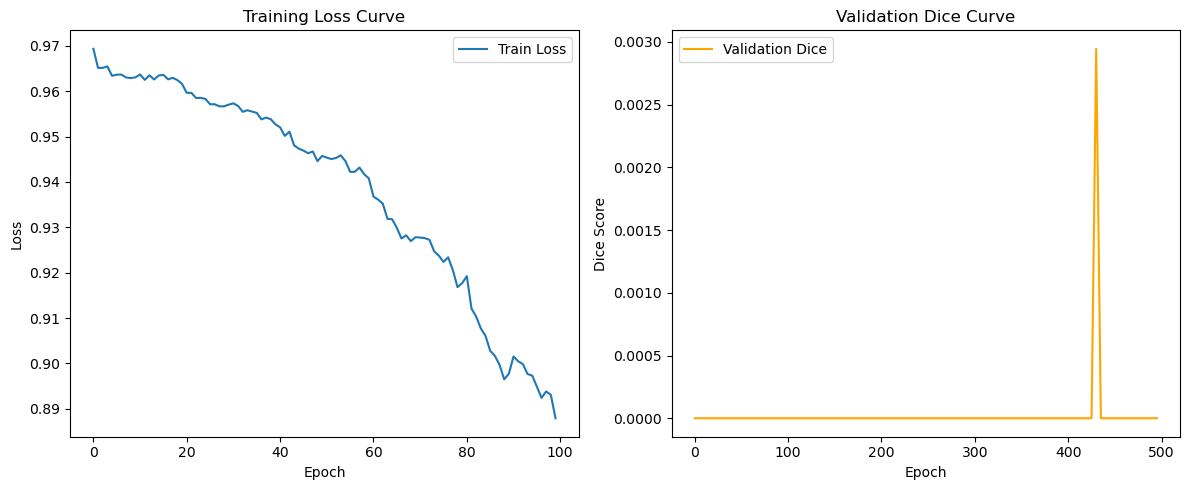


=== Training Model: attention_unet | Loss: tversky ===

Epoch 1/100
   [DEBUG] Loss: 0.986667
   [DEBUG] Loss: 0.962962
   [DEBUG] Loss: 0.964976
   [DEBUG] Loss: 0.984128
   [DEBUG] Loss: 0.995567
   [DEBUG] Loss: 0.978036
   [DEBUG] Loss: 0.978366
   [DEBUG] Loss: 0.964119
   🔹 Avg Train Loss: 0.9769
   [DEBUG] Val Output Mean: 0.379894, Max: 0.999500
   [DEBUG] Soft Dice (pre-threshold): 0.058332
   [DEBUG] Val Output Mean: 0.375495, Max: 0.999379
   [DEBUG] Soft Dice (pre-threshold): 0.030144
   🎯 Validation Dice (thresholded): 0.0000

Epoch 2/100
   [DEBUG] Loss: 0.965120
   [DEBUG] Loss: 0.976883
   [DEBUG] Loss: 0.955651
   [DEBUG] Loss: 0.977522
   [DEBUG] Loss: 0.963062
   [DEBUG] Loss: 0.963506
   [DEBUG] Loss: 0.982604
   [DEBUG] Loss: 0.994681
   🔹 Avg Train Loss: 0.9724
   [DEBUG] Val Output Mean: 0.371155, Max: 0.999250
   [DEBUG] Soft Dice (pre-threshold): 0.060319
   [DEBUG] Val Output Mean: 0.366169, Max: 0.999169
   [DEBUG] Soft Dice (pre-threshold): 0.031405
   🎯 Va

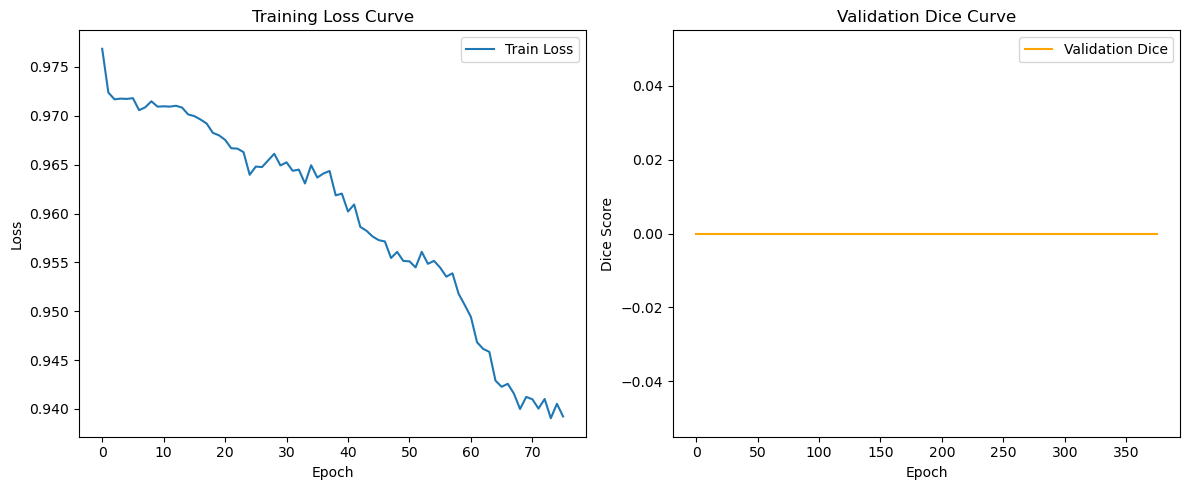


===== Summary of Preselection Results =====
Model:            unet, Loss:   bce_dice, Best Dice: 0.0750
Model:            unet, Loss:       dice, Best Dice: 0.0299
Model:            unet, Loss:    tversky, Best Dice: 0.0734
Model:   dynunet_no_ds, Loss:   bce_dice, Best Dice: 0.3084
Model:   dynunet_no_ds, Loss:       dice, Best Dice: 0.2303
Model:   dynunet_no_ds, Loss:    tversky, Best Dice: 0.1870
Model:  attention_unet, Loss:   bce_dice, Best Dice: 0.2347
Model:  attention_unet, Loss:       dice, Best Dice: 0.0029
Model:  attention_unet, Loss:    tversky, Best Dice: 0.0000


In [3]:
# === Preselection Loop ===
models_to_try = ["unet", "dynunet_no_ds", "attention_unet"]
losses_to_try = ["bce_dice", "dice", "tversky"]

results = []

for model_name in models_to_try:
    for loss_name in losses_to_try:
        print(f"\n=== Training Model: {model_name} | Loss: {loss_name} ===")

        model = get_model(model_name=model_name)
        loss_fn = loss_functions[loss_name]
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
        scheduler = CosineAnnealingLR(optimizer, T_max=10)  # fast config

        history, best_dice = train_and_validate(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            scheduler=scheduler,
            max_epochs=100,  
            model_path="outputs/",
            save_name=f"{model_name}_{loss_name}_preview.pth",
            validate_every=1,
            fast_until_epoch=20, 
            fast_roi_size=(96, 96, 96),  # smaller patch
            full_roi_size=(96, 96, 96),
            fast_overlap=0.1,
            full_overlap=0.1,
            fast_sw_batch_size=1,
            full_sw_batch_size=1,
            debug=True,
            early_training=True,   
            early_stop_min_delta=0.001
        )

        results.append({
            "model": model_name,
            "loss": loss_name,
            "best_dice": best_dice
        })

# === Print Results Summary ===
print("\n===== Summary of Preselection Results =====")
for res in results:
    print(f"Model: {res['model']:>15}, Loss: {res['loss']:>10}, Best Dice: {res['best_dice']:.4f}")

In [14]:
# === Full Dataset Loading ===
base_dir = "/datasets/tdt4265/mic/open/HNTS-MRG/train"
patients = sorted(glob.glob(os.path.join(base_dir, "*")))

train_files = []
for p in patients:
    t2_glob = glob.glob(os.path.join(p, "preRT", "*T2.nii.gz"))
    mask_glob = glob.glob(os.path.join(p, "preRT", "*mask.nii.gz"))
    if len(t2_glob) == 1 and len(mask_glob) == 1:
        train_files.append({"image": t2_glob[0], "label": mask_glob[0]})
    else:
        print(f"⚠️ Skipping {p} (found {len(t2_glob)} T2, {len(mask_glob)} masks)")

# Split into training and validation
train_split, val_split = train_test_split(train_files, test_size=0.2, random_state=42)

# === Create Dataloaders ===
batch_size = 2  # Adjust if needed
num_workers = 4  # Adjust for your machine
train_loader, val_loader = get_dataloaders(train_split, val_split, batch_size=batch_size, num_workers=num_workers)

print(f"✅ Loaded full dataset: {len(train_split)} training samples, {len(val_split)} validation samples.")

Loading dataset: 100%|██████████████████████████| 26/26 [00:15<00:00,  1.63it/s]

✅ Loaded full dataset: 104 training samples, 26 validation samples.


In [ ]:
# Config
model_name = "dynunet_no_ds"
loss_fun = "bce_dice"
save_name = "dynunet_no_ds_bce_dice_tuned.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
max_epochs = 500

# Load model
model = get_model(model_name=model_name)

# Loss function: BCE + Dice combined
loss_fn = loss_functions[loss_fun]

# Optimizer
optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

# Sart training
history, best_dice = train_and_validate(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    max_epochs=max_epochs,
    save_name=save_name,
    validate_every=5,
    early_stop_patience=20,
    early_stop_min_num_epochs=100,               # Enforced minimum training time
    early_stop_min_delta=0.001,                  # Small required improvement
    debug=False
)

print(f"🏆 Final Best Dice Score: {best_dice:.4f}")


In [3]:
# === Configuration ===
model_name = "dynunet_no_ds"
save_path = "outputs/best_model.pthdynunet_no_ds_bce_dice_tuned.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Load model ===
model = get_model(model_name=model_name, deep_supervision=False)
model.load_state_dict(torch.load(save_path, map_location=device))
model.to(device)
model.eval()


/tmp/ipykernel_822549/1628350536.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path, map_location=device))


DynUNet(
  (input_block): UnetBasicBlock(
    (conv1): Convolution(
      (conv): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
    )
    (conv2): Convolution(
      (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
    )
    (lrelu): LeakyReLU(negative_slope=0.01, inplace=True)
    (norm1): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (norm2): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
  )
  (downsamples): ModuleList(
    (0): UnetBasicBlock(
      (conv1): Convolution(
        (conv): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
      )
      (conv2): Convolution(
        (conv): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      )
      (lrelu): LeakyReLU(negative_slope=0.01, inplace=True)
      (norm1): InstanceNorm3d(32, eps=1e-05

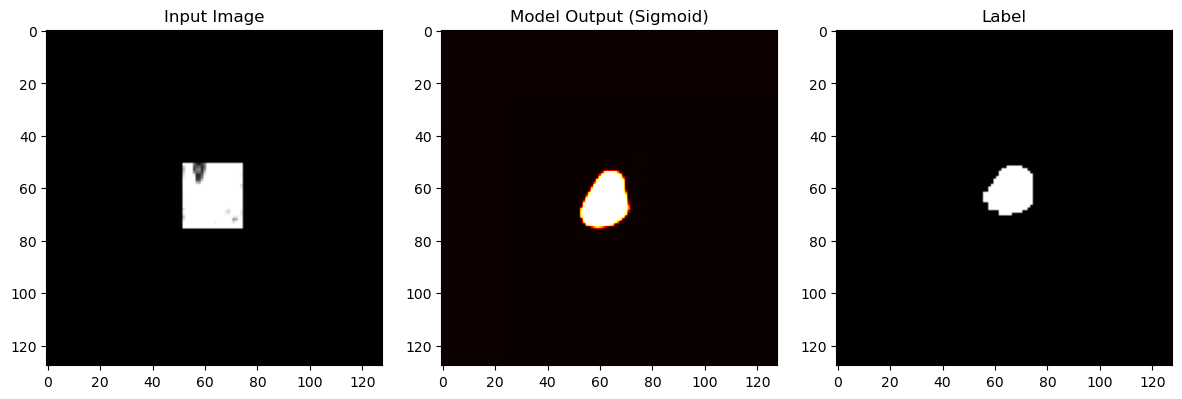

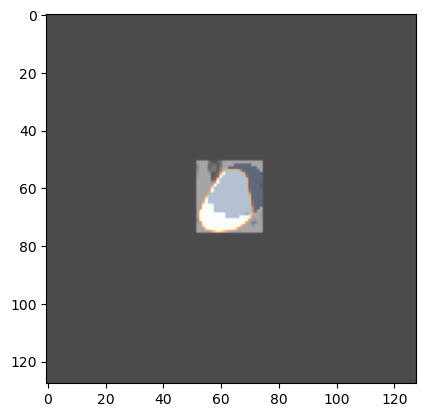

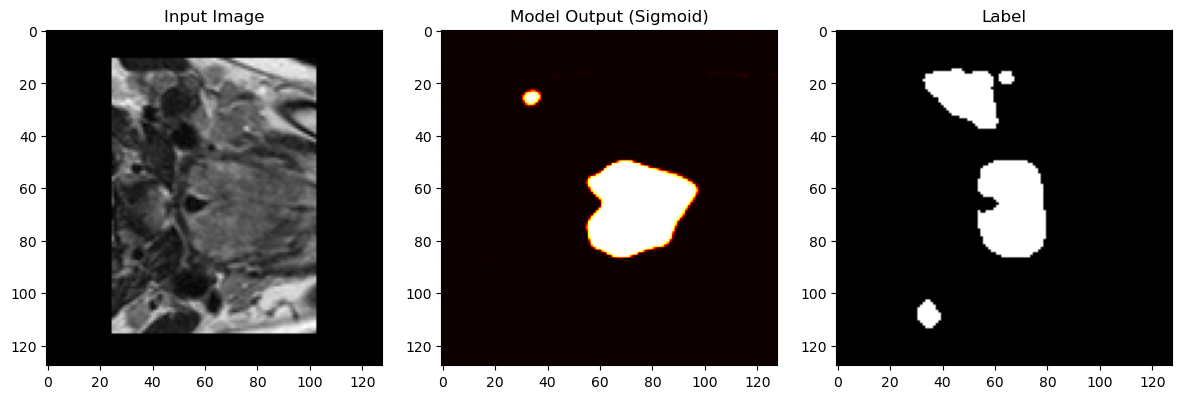

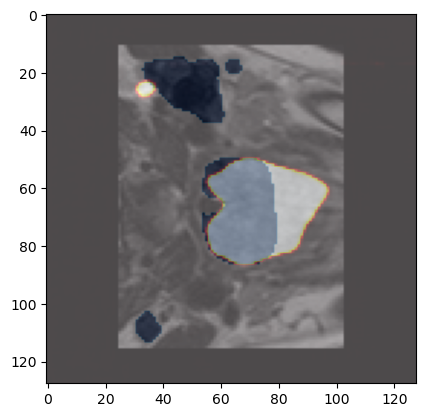

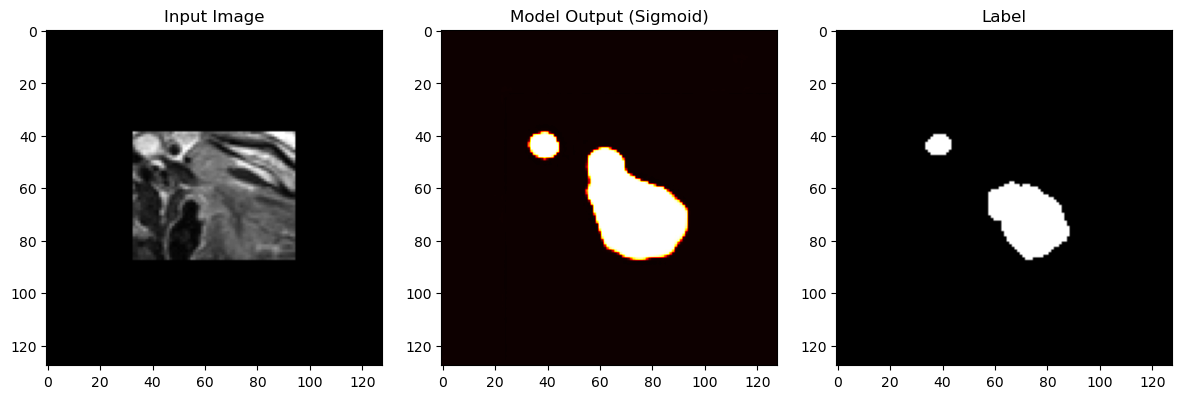

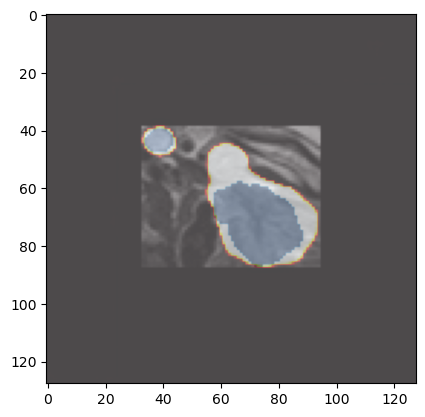

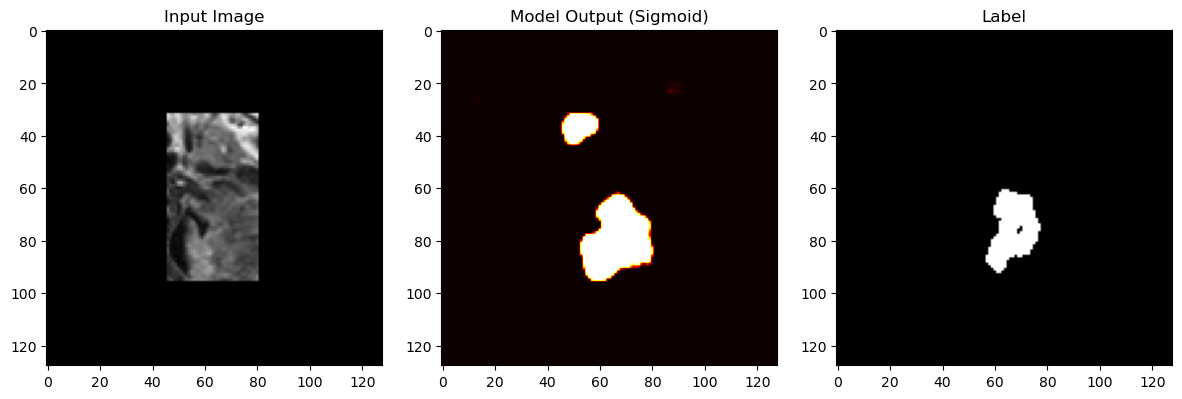

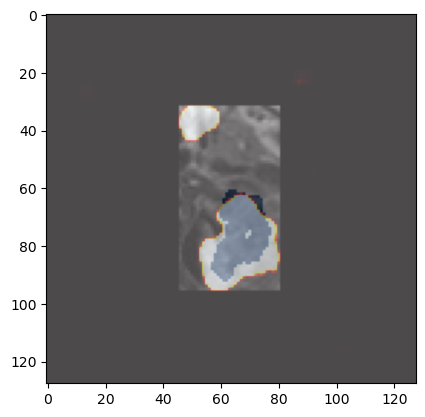

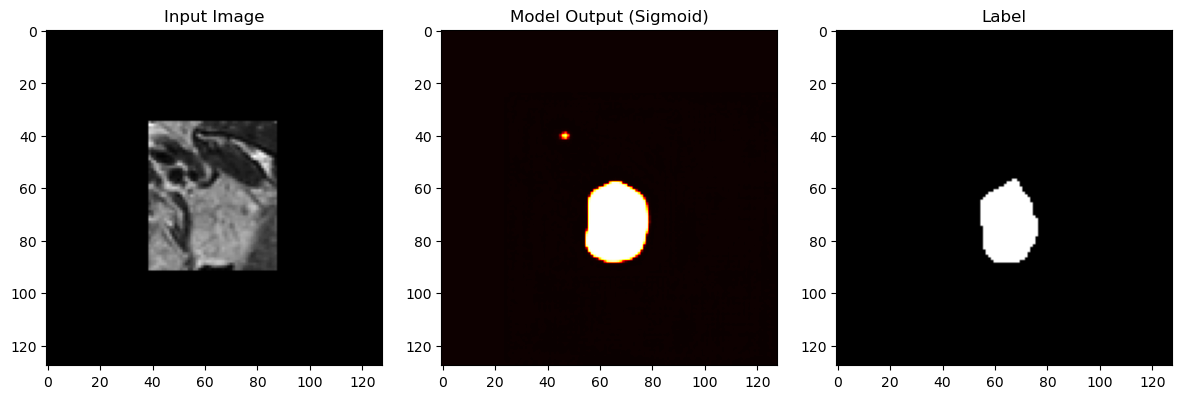

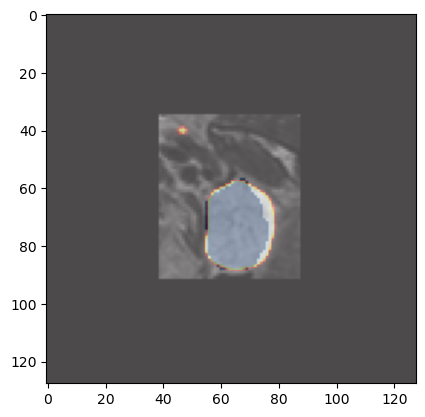

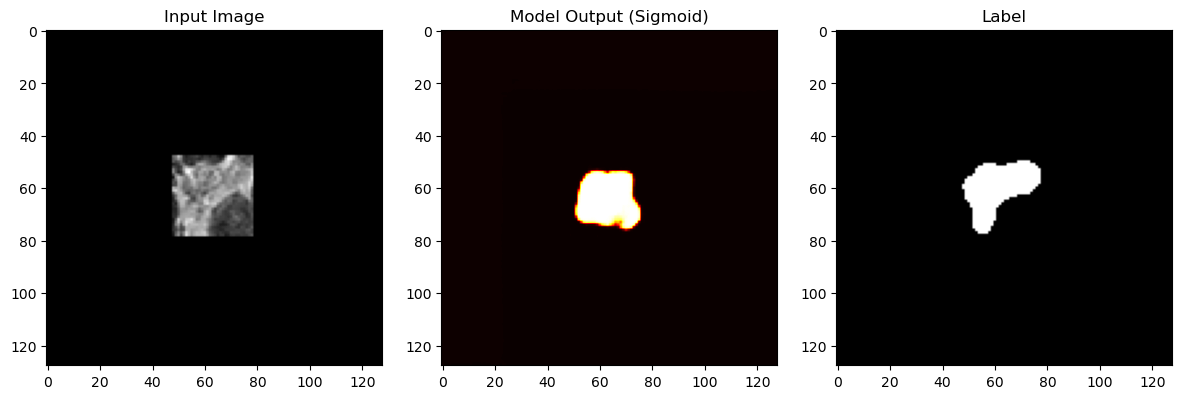

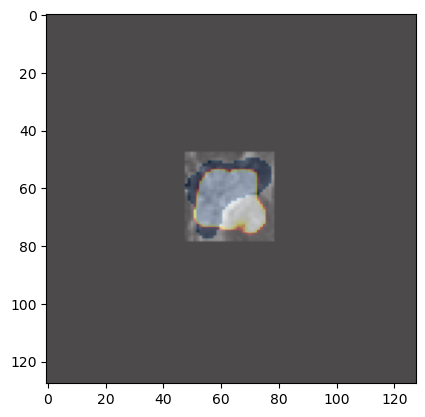

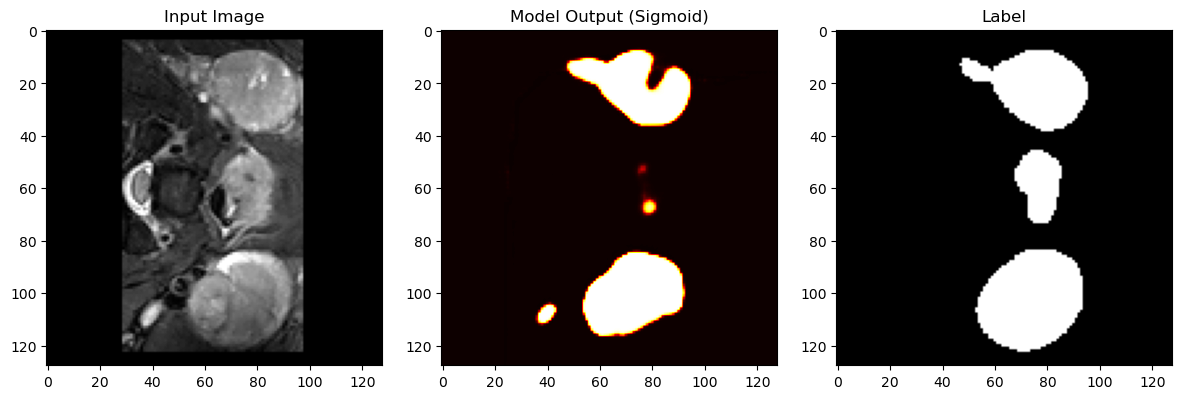

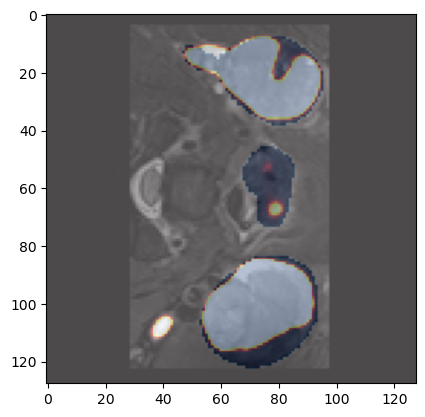

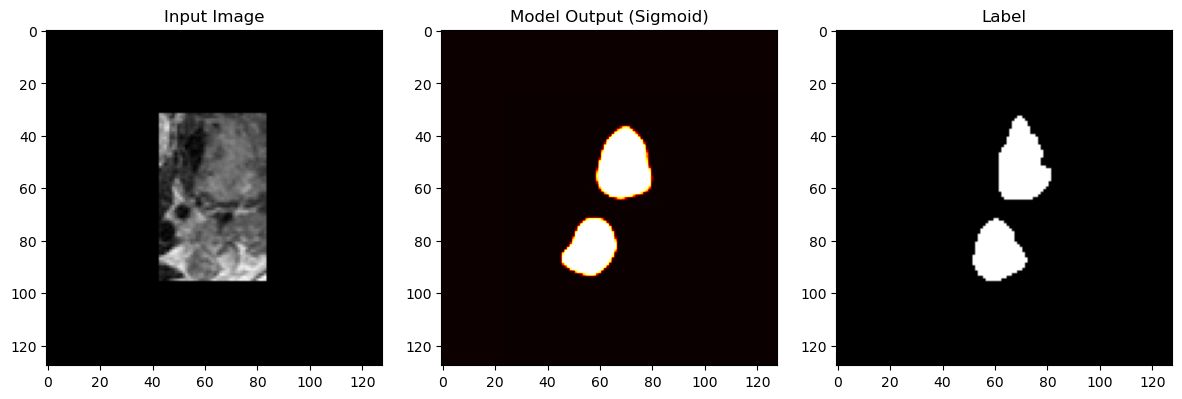

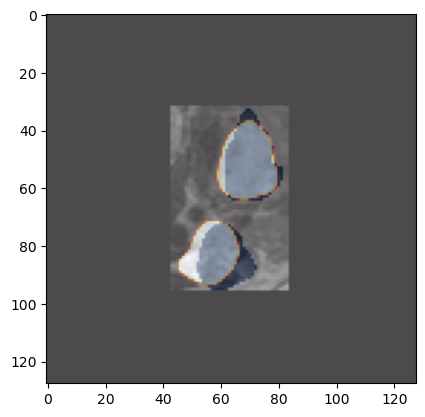

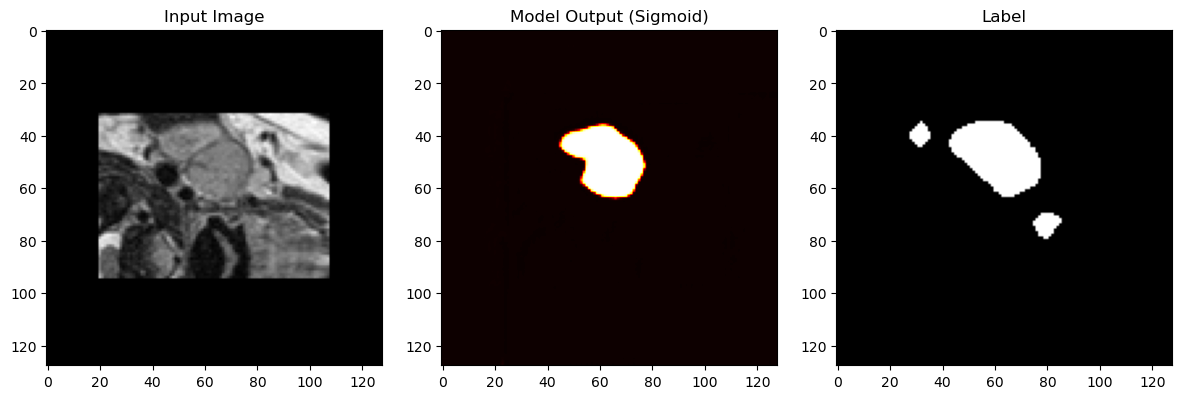

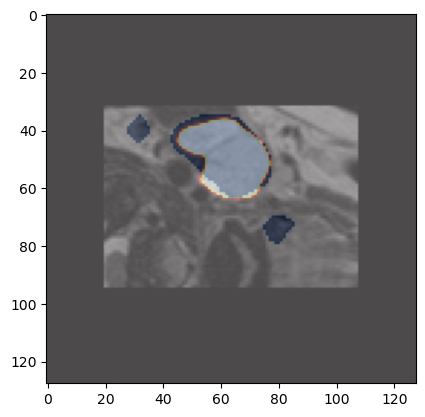

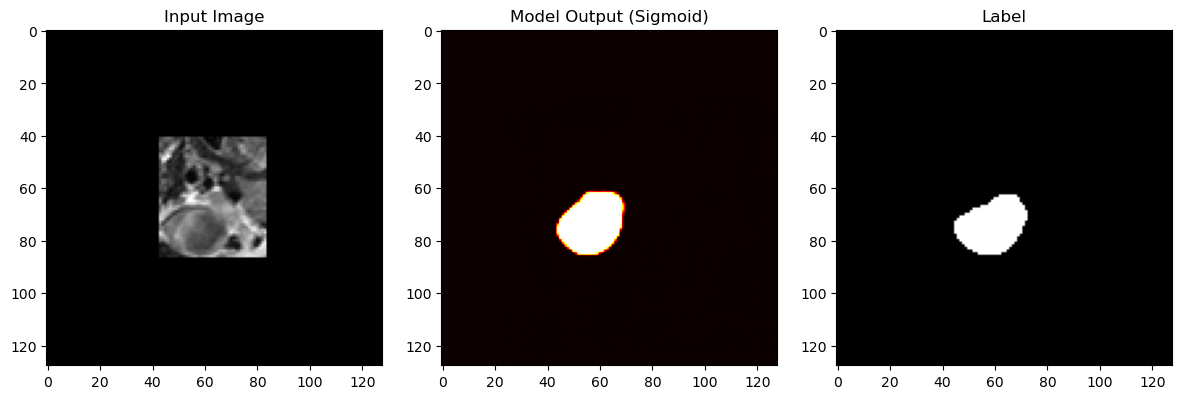

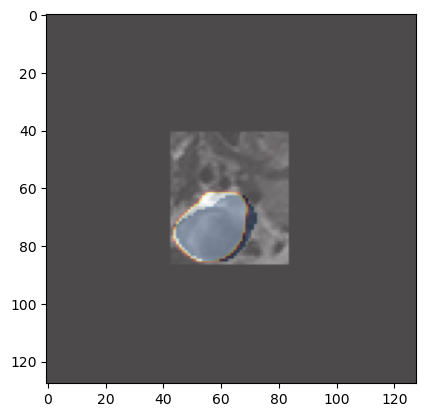

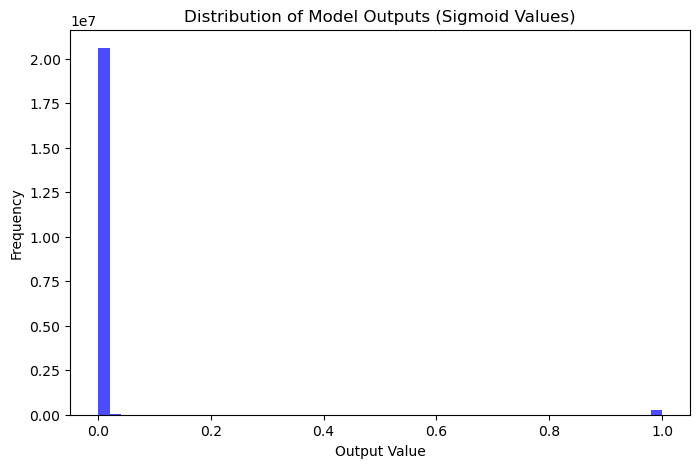

In [4]:
model.to(device)

# Visualize predictions on a few validation samples
analyze_validation_outputs(val_loader, model, device, num_batches=10)

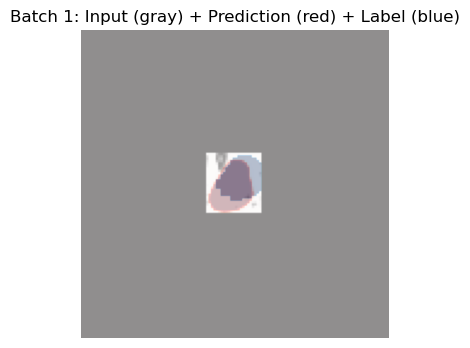

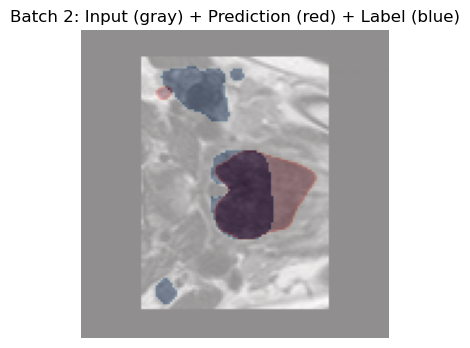

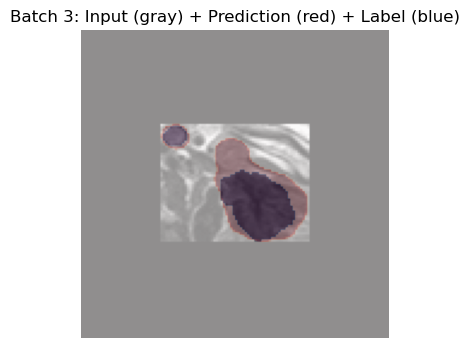

In [5]:
import torch
import matplotlib.pyplot as plt

model.eval()
num_batches = 3  # You can increase this if needed

with torch.no_grad():
    for idx, val_data in enumerate(val_loader):
        if idx >= num_batches:
            break

        val_inputs = val_data["image"].to(device)
        val_labels = val_data["label"].to(device)
        val_outputs = torch.sigmoid(model(val_inputs))

        # Slice index (middle slice)
        slice_idx = val_inputs.shape[4] // 2

        # Plot overlay
        plt.figure(figsize=(12, 4))
        plt.title(f"Batch {idx+1}: Input (gray) + Prediction (red) + Label (blue)")
        plt.imshow(val_inputs[0, 0, :, :, slice_idx].cpu(), cmap="gray")
        plt.imshow(val_outputs[0, 0, :, :, slice_idx].cpu(), cmap="Reds", alpha=0.4)
        plt.imshow(val_labels[0, 0, :, :, slice_idx].cpu(), cmap="Blues", alpha=0.3)
        plt.axis("off")
        plt.show()


In [5]:
model.eval()
all_dices = []

with torch.no_grad():
    for val_data in val_loader:
        val_inputs = val_data["image"].to(device)
        val_labels = val_data["label"].to(device)
        
        val_outputs = torch.sigmoid(model(val_inputs))
        val_pred_bin = (val_outputs > 0.5).float()

        # Use your dice_debug function to print details
        dices = dice_debug(val_pred_bin, val_labels)  # This returns a tensor of per-sample dice
        all_dices.extend(dices.cpu().numpy().tolist())  # collect all dice values

# === After all batches ===
average_dice = np.mean(all_dices)
print(f"\n🎯 Global Average Dice over {len(all_dices)} samples: {average_dice:.4f}")


🧪 Sample 1:
   ➤ Prediction voxels: 10087
   ➤ Ground Truth voxels: 5155
   ➤ Intersection voxels: 4212
   🎯 Dice: 0.5527
----------------------------------------
🧪 Sample 1:
   ➤ Prediction voxels: 47528
   ➤ Ground Truth voxels: 47844
   ➤ Intersection voxels: 26031
   🎯 Dice: 0.5459
----------------------------------------
🧪 Sample 1:
   ➤ Prediction voxels: 28485
   ➤ Ground Truth voxels: 17921
   ➤ Intersection voxels: 16251
   🎯 Dice: 0.7004
----------------------------------------
🧪 Sample 1:
   ➤ Prediction voxels: 17057
   ➤ Ground Truth voxels: 11098
   ➤ Intersection voxels: 9186
   🎯 Dice: 0.6525
----------------------------------------
🧪 Sample 1:
   ➤ Prediction voxels: 25882
   ➤ Ground Truth voxels: 28644
   ➤ Intersection voxels: 23851
   🎯 Dice: 0.8748
----------------------------------------
🧪 Sample 1:
   ➤ Prediction voxels: 13985
   ➤ Ground Truth voxels: 11949
   ➤ Intersection voxels: 7801
   🎯 Dice: 0.6016
----------------------------------------
🧪 Sample 1:
  

🔧 Reset learning rate to 5e-05
🔄 Loading model weights from outputs/best_model.pthdynunet_no_ds_bce_dice_tuned.pth

Epoch 1/500


/home/marcosba/Downloads/medical_segmentation_project/train.py:45: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/home/marcosba/Downloads/medical_segmentation_project/train.py:51: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True`

   🔹 Avg Train Loss: 0.3284
   🎯 Validation Soft Dice: 0.4120
   💾 Best model saved at outputs/best_model.pthdynunet_no_ds_bce_dice_tuned.pth.

Epoch 2/500
   🔹 Avg Train Loss: 0.3275

Epoch 3/500
   🔹 Avg Train Loss: 0.3266

Epoch 4/500
   🔹 Avg Train Loss: 0.3264

Epoch 5/500
   🔹 Avg Train Loss: 0.3277

Epoch 6/500
   🔹 Avg Train Loss: 0.3279
   🎯 Validation Soft Dice: 0.4373
   💾 Best model saved at outputs/best_model.pthdynunet_no_ds_bce_dice_tuned.pth.

Epoch 7/500
   🔹 Avg Train Loss: 0.3291

Epoch 8/500
   🔹 Avg Train Loss: 0.3276

Epoch 9/500
   🔹 Avg Train Loss: 0.3242

Epoch 10/500
   🔹 Avg Train Loss: 0.3240

Epoch 11/500
   🔹 Avg Train Loss: 0.3209
   🎯 Validation Soft Dice: 0.4445
   💾 Best model saved at outputs/best_model.pthdynunet_no_ds_bce_dice_tuned.pth.

Epoch 12/500
   🔹 Avg Train Loss: 0.3194

Epoch 13/500
   🔹 Avg Train Loss: 0.3157

Epoch 14/500
   🔹 Avg Train Loss: 0.3154

Epoch 15/500
   🔹 Avg Train Loss: 0.3129

Epoch 16/500
   🔹 Avg Train Loss: 0.3109
   🎯 

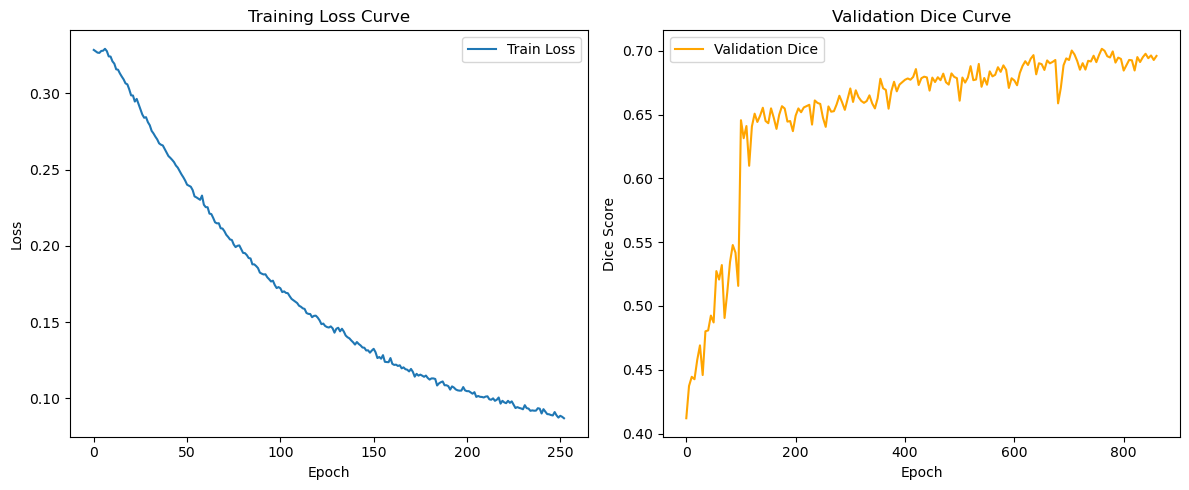

🏆 Final Best Dice Score: 0.7016


In [3]:
# Config
model_name = "dynunet_no_ds"
loss_fun = "bce_dice"
save_name = "dynunet_no_ds_bce_dice_tuned.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
max_epochs = 500

# Load model
model = get_model(model_name=model_name)

# Loss function: BCE + Dice combined
loss_fn = loss_functions[loss_fun]

# Optimizer
optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
for param_group in optimizer.param_groups:
    param_group['lr'] = 5e-5  # ← smaller learning rate for fine-tuning
print(f"🔧 Reset learning rate to {optimizer.param_groups[0]['lr']}")

# Start training
history, best_dice = train_and_validate(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    max_epochs=max_epochs,
    save_name=save_name,
    load_existing=True,                
    validate_every=5,
    early_stop_patience=20,
    early_stop_min_num_epochs=100,
    early_stop_min_delta=0.001,
    debug=False
)

print(f"🏆 Final Best Dice Score: {best_dice:.4f}")


In [2]:
# === Configuration ===
model_name = "dynunet_no_ds"
save_path = "outputs/best_model.pthdynunet_no_ds_bce_dice_tuned.pth"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Load model ===
model = get_model(model_name=model_name, deep_supervision=False)
model.load_state_dict(torch.load(save_path, map_location=device))
model.to(device)
model.eval()

/tmp/ipykernel_48627/3136191189.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path, map_location=device))


DynUNet(
  (input_block): UnetBasicBlock(
    (conv1): Convolution(
      (conv): Conv3d(1, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
    )
    (conv2): Convolution(
      (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
    )
    (lrelu): LeakyReLU(negative_slope=0.01, inplace=True)
    (norm1): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (norm2): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
  )
  (downsamples): ModuleList(
    (0): UnetBasicBlock(
      (conv1): Convolution(
        (conv): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
      )
      (conv2): Convolution(
        (conv): Conv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
      )
      (lrelu): LeakyReLU(negative_slope=0.01, inplace=True)
      (norm1): InstanceNorm3d(32, eps=1e-05

In [3]:
# Load test paths
test_dir = "/datasets/tdt4265/mic/open/HNTS-MRG/test"
test_patients = sorted(glob.glob(os.path.join(test_dir, "*")))

test_files = []
for p in test_patients:
    t2 = glob.glob(os.path.join(p, "preRT", "*T2.nii.gz"))
    mask = glob.glob(os.path.join(p, "preRT", "*mask.nii.gz"))
    if len(t2) == 1 and len(mask) == 1:
        test_files.append({"image": t2[0], "label": mask[0]})
    else:
        print(f"⚠️ Skipping {p}: found {len(t2)} T2 and {len(mask)} masks")

# Create test dataset and loader with metadata preserved
test_ds = Dataset(
    data=test_files,
    transform=get_test_transforms()
)

test_loader = DataLoader(
    test_ds,
    batch_size=1,
    shuffle=False,
    num_workers=4,
    collate_fn=list_data_collate  
)


/usr/local/lib/python3.10/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)


In [7]:
dice_metric = DiceMetric(include_background=False, reduction="mean")
dice_metric.reset()

with torch.no_grad():
    for data in test_loader:
        inputs = data["image"].to(device)
        labels = data["label"].to(device)

        outputs = torch.sigmoid(sliding_window_inference(
            inputs, roi_size=(128, 128, 128), sw_batch_size=1, predictor=model, overlap=0.25
        ))

        preds_bin = (outputs > 0.5).float()
        dice_metric(y_pred=preds_bin, y=labels)

# Final Dice
mean_dice = dice_metric.aggregate().item()
print(f"\n🧪 Average Test Dice (MONAI): {mean_dice:.4f}")


🧪 Average Test Dice (MONAI): 0.7024


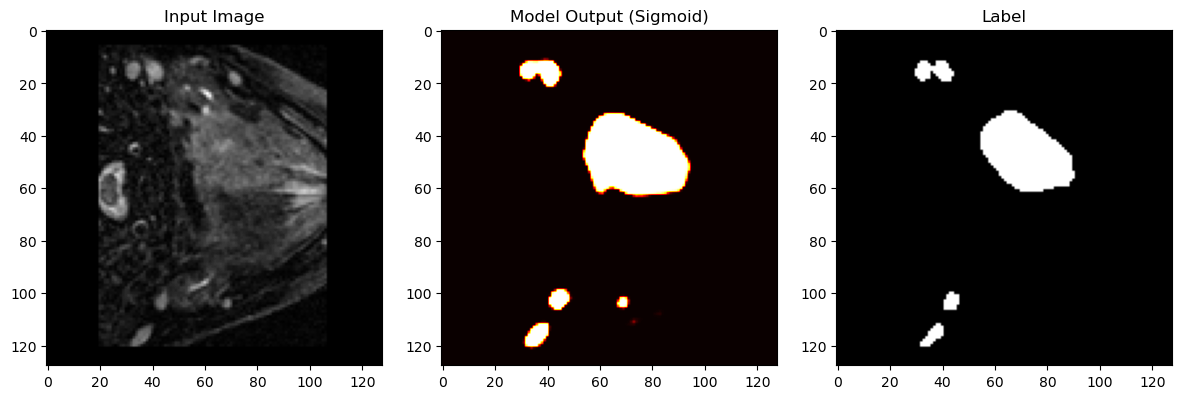

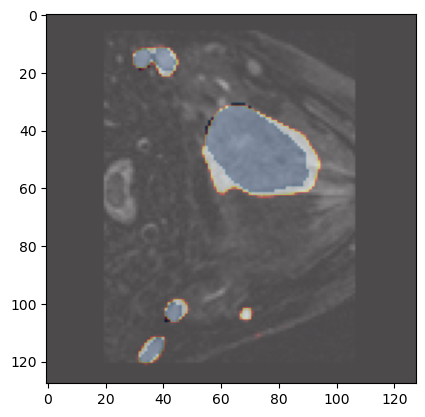

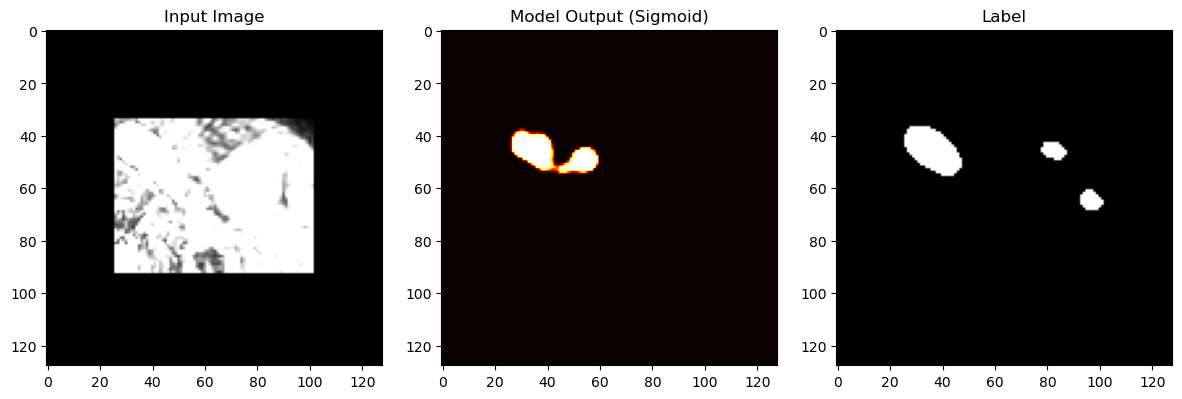

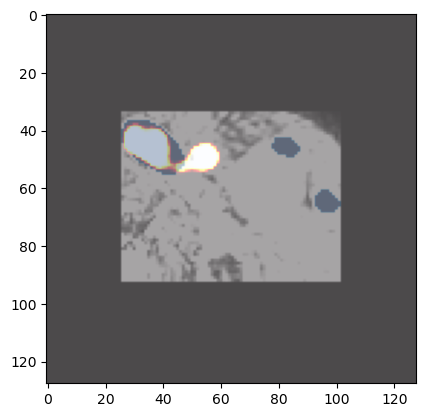

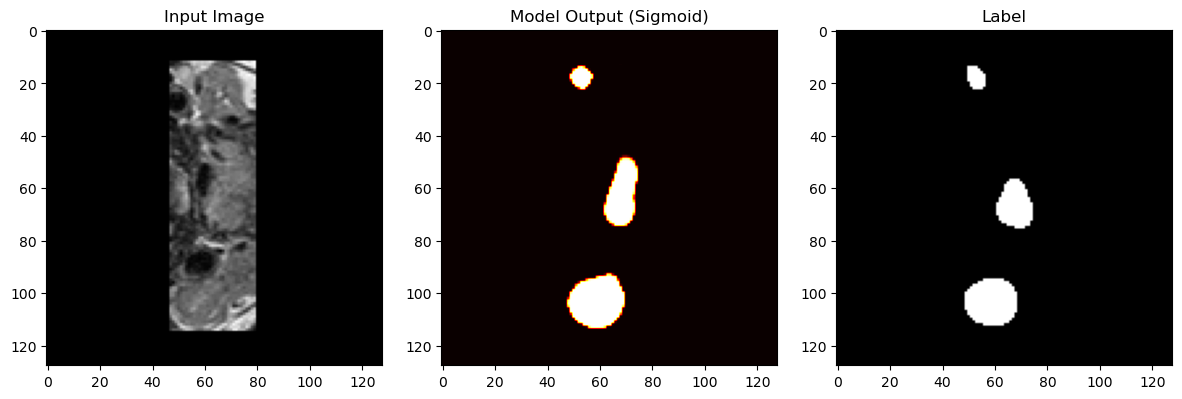

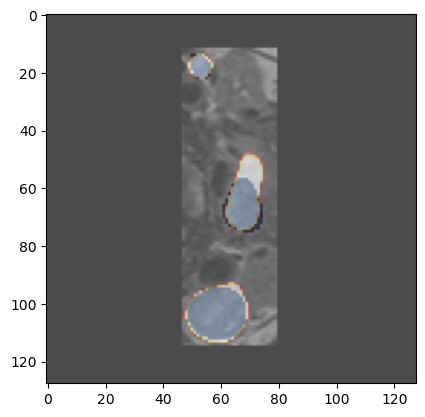

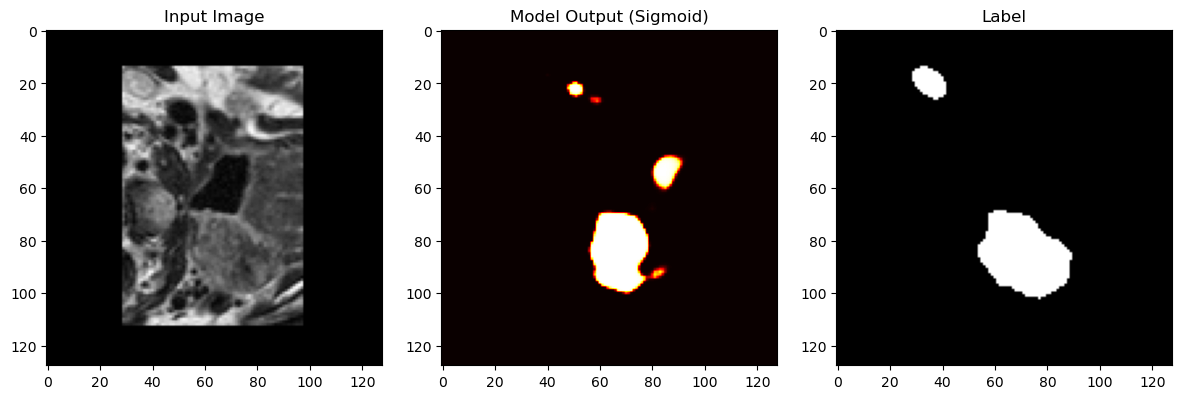

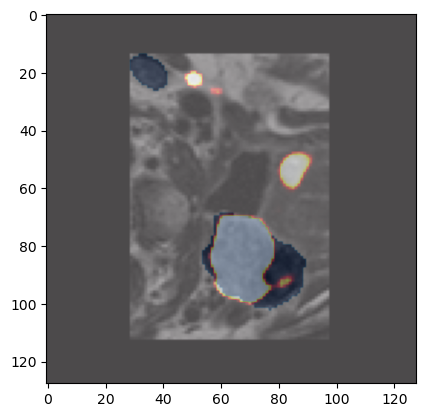

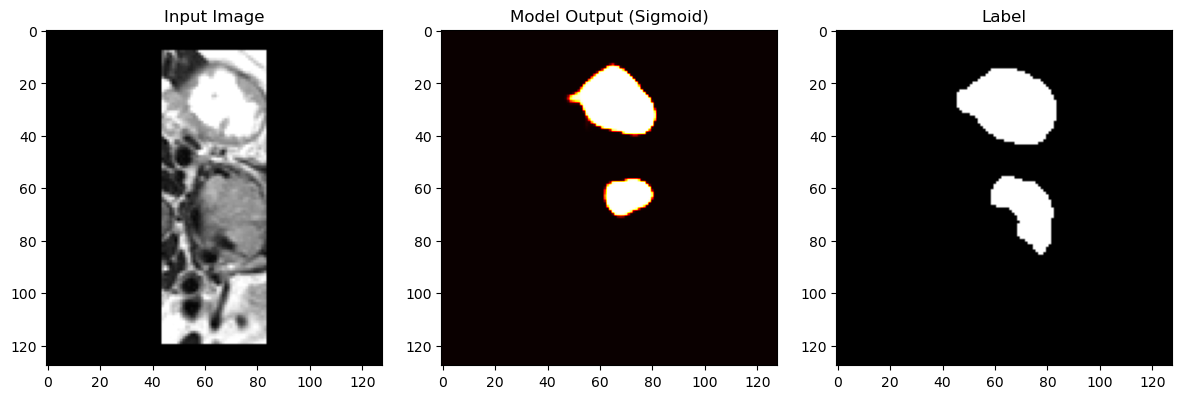

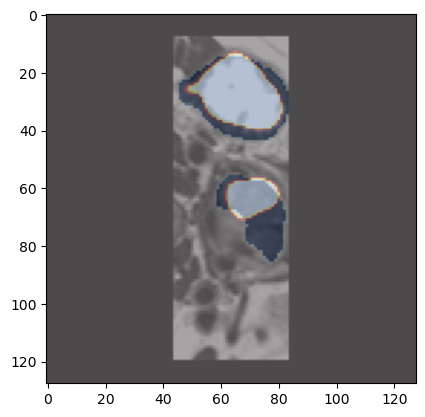

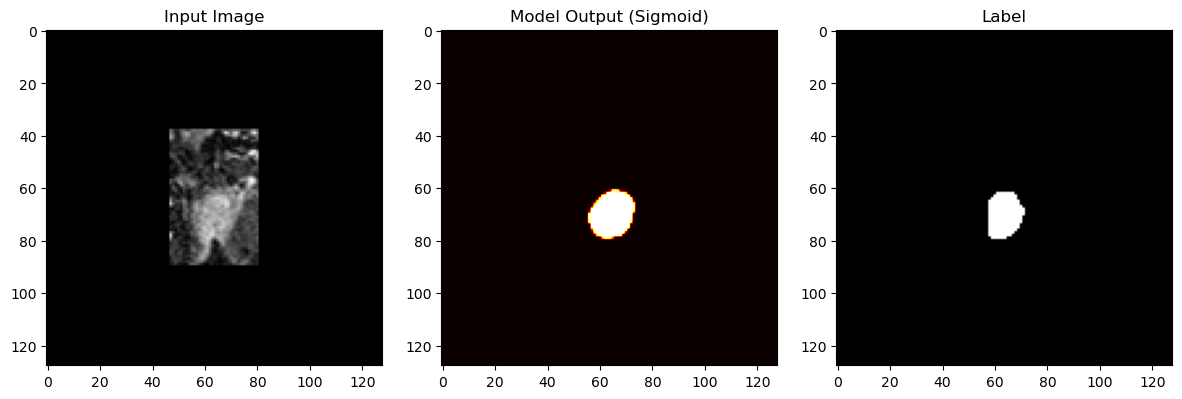

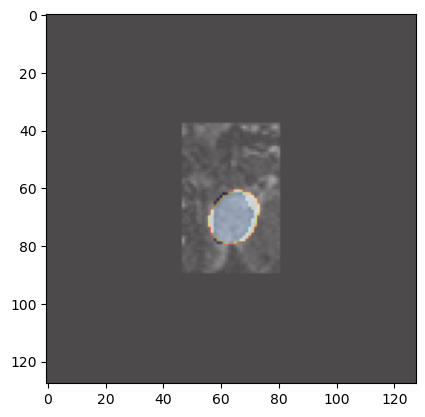

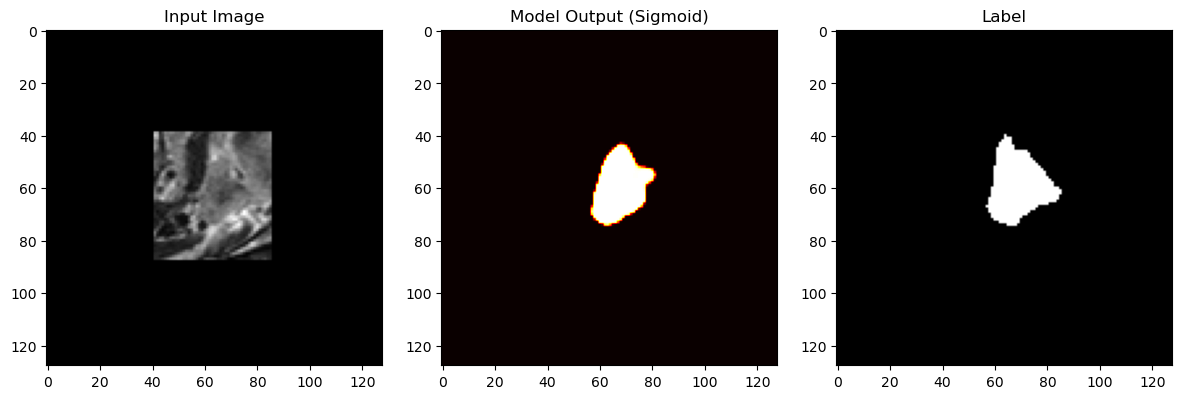

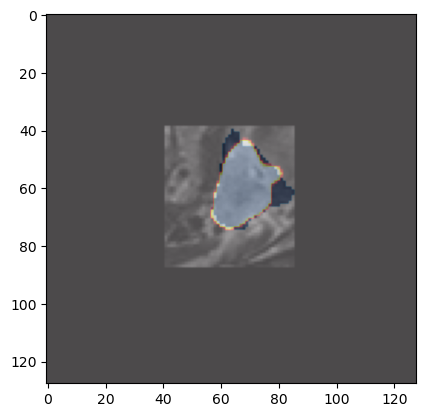

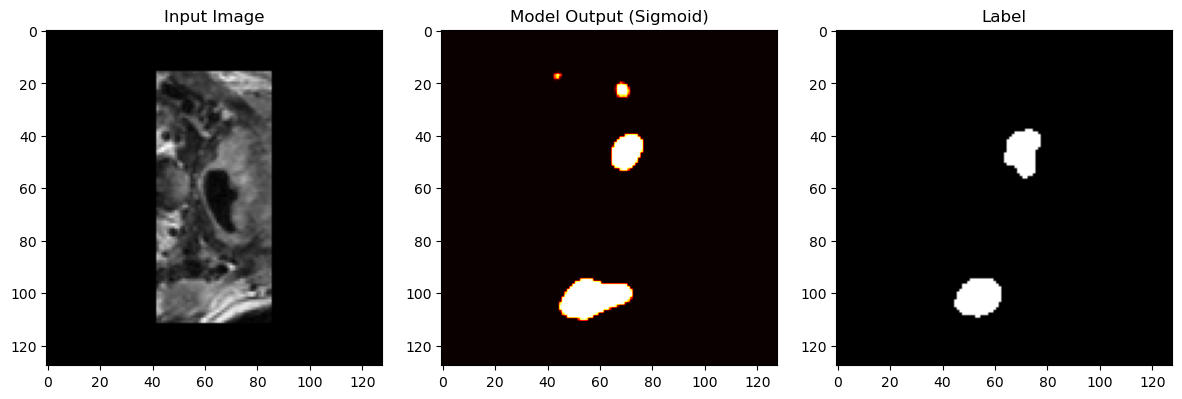

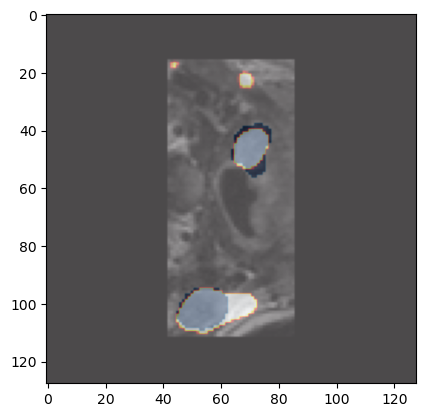

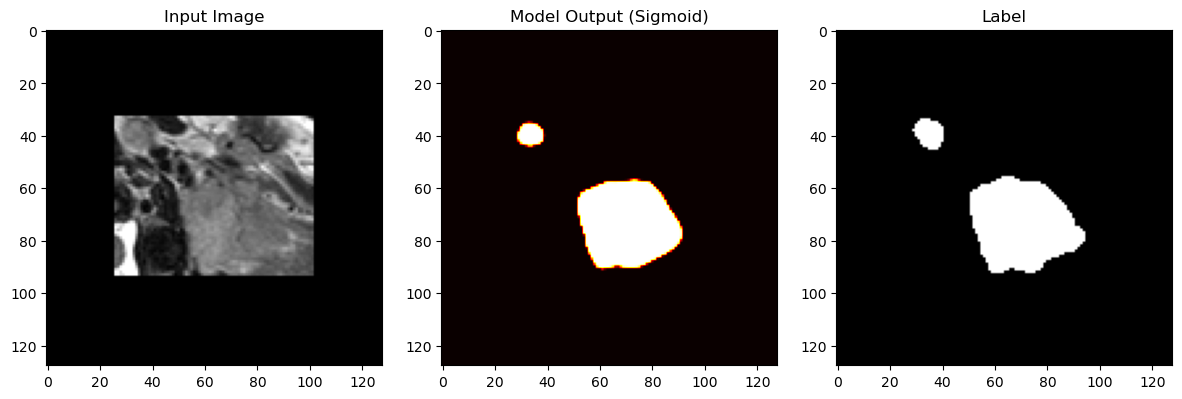

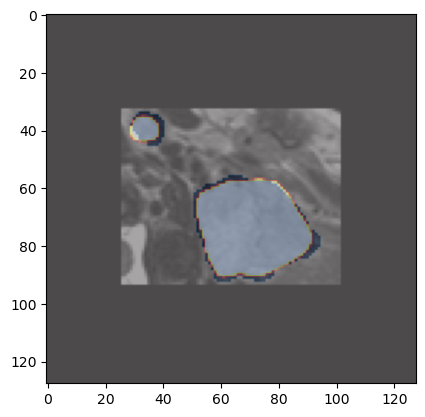

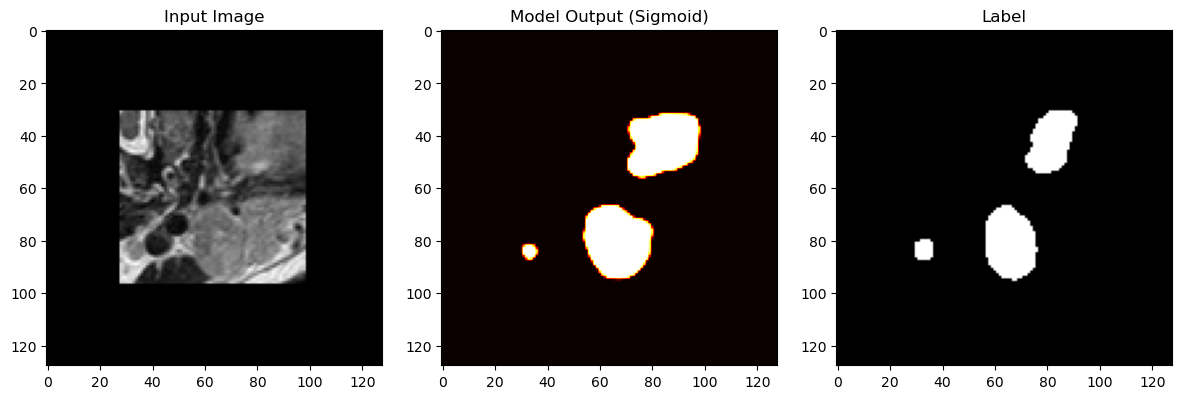

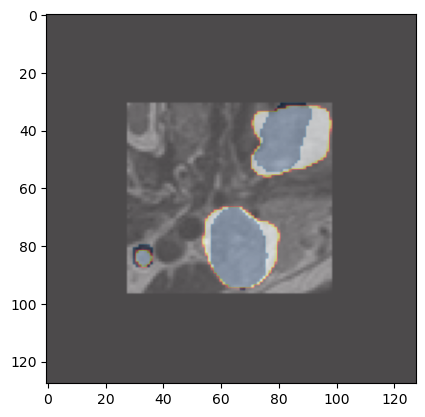

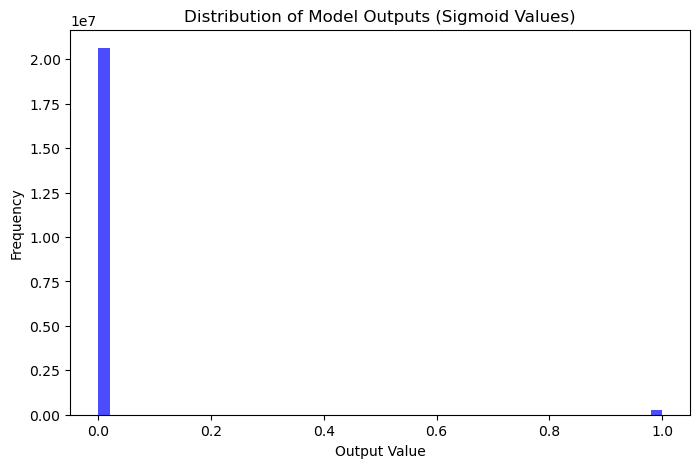

In [21]:
# Visualize predictions on a few validation samples
analyze_validation_outputs(test_loader, model, device, num_batches=10)

In [4]:
save_ranked_predictions_for_slicer(
    model=model,
    test_loader=test_loader,
    save_dir="slicer_exports",
    device=device,  
    N=3               # Saves 3 best, 3 mid, 3 worst = 9 cases total
)

Evaluating batches...


Evaluating batches: 100%|███████████████████████| 20/20 [00:14<00:00,  1.33it/s]


✅ Saved 9 volumes (best, worst, mid) to slicer_exports
